# Setup

In [ ]:
%%capture cap
!pip install scanpy
!pip install scanpy umap-learn
!pip install leidenalg
!pip install statannotations
!pip install adjustText statsmodels
!pip install scikit-posthocs
!pip install upsetplot
!pip install gprofiler-official pandas seaborn matplotlib openpyxl

In [ ]:
# Standard library
import math
import re
from itertools import combinations

# Numerical & data handling
import numpy as np
import pandas as pd
import networkx as nx

# Statistics
from scipy.stats import (
    pearsonr, spearmanr, kruskal, mannwhitneyu,
    ttest_ind, chi2
)
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp

# Plot annotation & adjustment
from statannotations.Annotator import Annotator
from adjustText import adjust_text

# Single-cell analysis
import scanpy as sc

# Plotting - Matplotlib & Seaborn
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
from matplotlib import font_manager as fm
import seaborn as sns

# Plotting - Plotly
import plotly.graph_objects as go
import plotly.express as px

# Set analysis / intersections
from upsetplot import UpSet, from_memberships

# GO
from gprofiler import GProfiler
from itertools import combinations

In [ ]:
font_path = "/content/ARIAL.TTF"

fm.fontManager.addfont(font_path)

mpl.rcParams['font.family'] = 'Arial'

In [ ]:
plt.rcParams['axes.labelsize'] = 26
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['xtick.labelsize'] = 26
plt.rcParams['ytick.labelsize'] = 26
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['font.family'] = 'Arial'

In [ ]:
!mkdir -p figures/HeLa
!mkdir -p figures/PBMC_benchmarking
!mkdir -p figures/PBMC_patients
!mkdir -p figures/monocytes
!mkdir -p figures/lymphocytes
!mkdir -p figures/QC
!mkdir -p table_markers
!mkdir -p table_umap

# HeLa single-cell

In [ ]:
file_path = "PG_HeLa_Paper_Storage_DIA-NN_2p3_report_report.pg_matrix.tsv"

In [ ]:
data = pd.read_csv(file_path, sep="\t", encoding='latin-1')
original_col_count = data.shape[1]
data = data.fillna(0)
data = data.loc[:, (data != 0).sum() >= 150]

filtered_col_count = data.shape[1]
removed_cols = original_col_count - filtered_col_count

In [ ]:
exclude_data = pd.read_excel("Blanks_Common_HeLa.xlsx")

ids_to_exclude = exclude_data.iloc[:, 0].tolist()

data = data[~data.iloc[:, 0].isin(ids_to_exclude)]

In [ ]:
condition_colors = {
    "Fresh37C": "#107732",
    "Fresh4C_1day": "#44aa99",
    "PFA_15min_1day": "#cc6677",
    "PFA_15min_8days": "#aa4499",
    "PFA_30min_1day": "#772d1f",
    "PFA_30min_8days": "#953b67",
    "Cryo-80C_1day": "#88ccee",
    "Cryo-80C_8days": "#38288b"
}

In [ ]:
transposed_data = data.set_index("Genes").transpose()

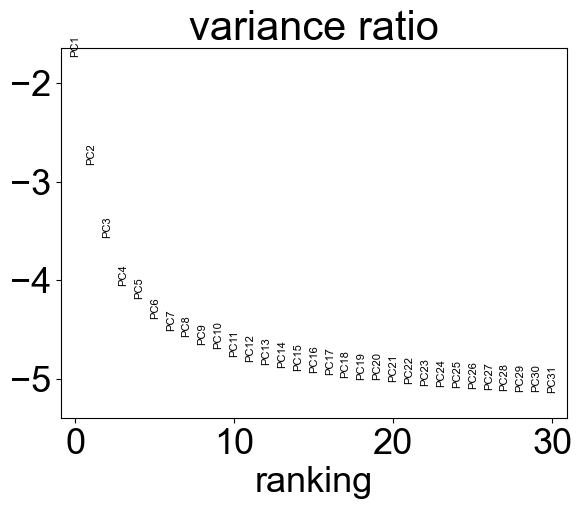

PC1: 17.69%
PC2: 23.61%
PC3: 26.43%
PC4: 28.16%
PC5: 29.68%
PC6: 30.92%
PC7: 32.02%
PC8: 33.06%
PC9: 34.01%
PC10: 34.92%
PC11: 35.75%
PC12: 36.55%
PC13: 37.33%
PC14: 38.08%
PC15: 38.81%
PC16: 39.52%
PC17: 40.23%
PC18: 40.91%
PC19: 41.57%
PC20: 42.24%
PC21: 42.89%
PC22: 43.53%
PC23: 44.15%
PC24: 44.77%
PC25: 45.39%
PC26: 46.00%
PC27: 46.60%
PC28: 47.19%
PC29: 47.79%
PC30: 48.37%
PC31: 48.96%
PC32: 49.54%
PC33: 50.11%
PC34: 50.68%
PC35: 51.24%
PC36: 51.80%
PC37: 52.36%
PC38: 52.91%
PC39: 53.46%
PC40: 54.00%
PC41: 54.54%
PC42: 55.08%
PC43: 55.61%
PC44: 56.14%
PC45: 56.67%
PC46: 57.19%
PC47: 57.71%
PC48: 58.23%
PC49: 58.74%
PC50: 59.26%
PC51: 59.76%
PC52: 60.27%
PC53: 60.77%
PC54: 61.27%
PC55: 61.76%
PC56: 62.25%
PC57: 62.74%
PC58: 63.22%
PC59: 63.70%
PC60: 64.18%
PC61: 64.66%
PC62: 65.13%
PC63: 65.60%
PC64: 66.07%
PC65: 66.53%
PC66: 66.99%
PC67: 67.46%
PC68: 67.91%
PC69: 68.37%
PC70: 68.82%
PC71: 69.27%
PC72: 69.72%
PC73: 70.16%
PC74: 70.60%
PC75: 71.04%
PC76: 71.48%
PC77: 71.91%
PC78: 72

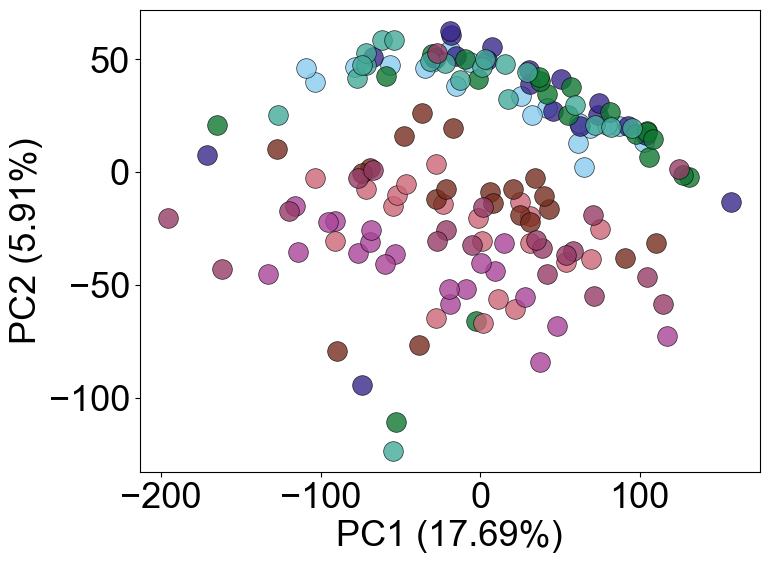

In [ ]:
valid_samples = [sample for sample in transposed_data.index if "_" in sample]

condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return "Unknown"

sample_conditions = [extract_condition(row) for row in transposed_data.index]

adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs["condition"] = sample_conditions
sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=100)

explained_variance_ratio = adata.uns["pca"]["variance_ratio"]
pc1_var = explained_variance_ratio[0] * 100
pc2_var = explained_variance_ratio[1] * 100

sc.pl.pca_variance_ratio(adata, log=True, n_pcs=30)

cumulative_variance = np.cumsum(adata.uns["pca"]["variance_ratio"])
for i, v in enumerate(cumulative_variance):
    print(f"PC{i+1}: {v*100:.2f}%")


plt.figure(figsize=(8, 6))

unique_conditions = [c for c in np.unique(sample_conditions) if c is not None]

pc1 = adata.obsm["X_pca"][:, 0]
pc2 = adata.obsm["X_pca"][:, 1]

for condition in unique_conditions:
    mask = np.array(sample_conditions) == condition
    plt.scatter(pc1[mask], pc2[mask], label=condition, color=condition_colors.get(condition, "#000000"), edgecolor='black', linewidth=0.5, alpha=0.8, s=200)


plt.xlabel(f"PC1 ({pc1_var:.2f}%)")
plt.ylabel(f"PC2 ({pc2_var:.2f}%)")
plt.title("")

plt.grid(False)
plt.savefig("figures/HeLa/PCA_HeLa.svg")

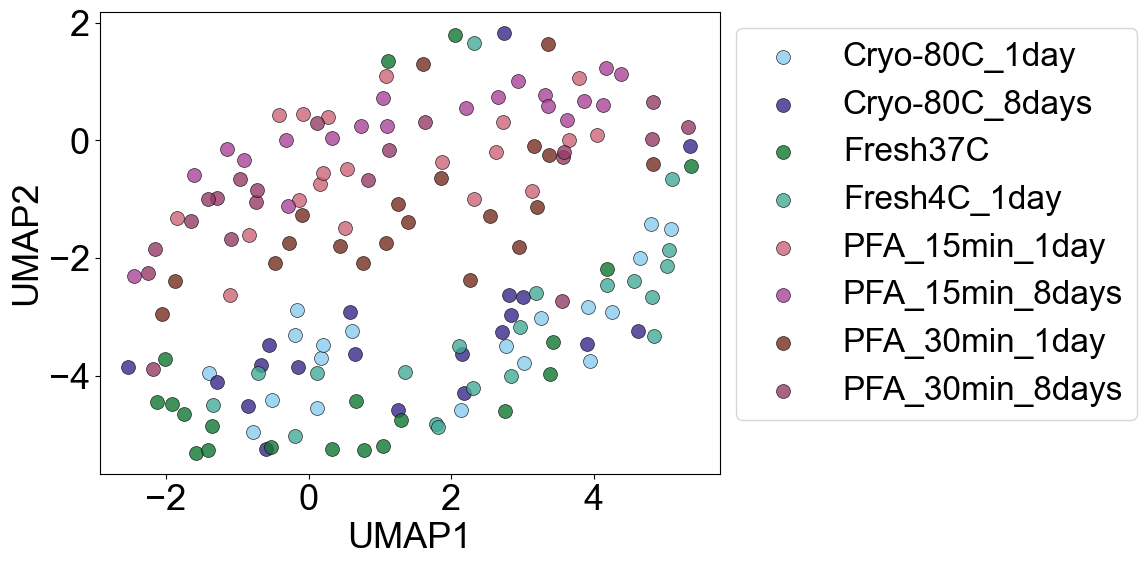

In [ ]:
filtered_data = transposed_data.loc[valid_samples]

obs_data = pd.DataFrame({"condition": sample_conditions}, index=valid_samples)

adata = sc.AnnData(filtered_data.values, obs=obs_data)

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=20)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

umap_results = adata.obsm["X_umap"]
umap1 = umap_results[:, 0]
umap2 = -umap_results[:, 1]

plt.figure(figsize=(8, 6))

for condition in np.unique(sample_conditions):
    mask = obs_data["condition"] == condition
    plt.scatter(umap1[mask], umap2[mask], label=condition,
                color=condition_colors.get(condition, "#000000"), alpha=0.8, s=100, edgecolor='black', linewidth=0.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.legend(title="", bbox_to_anchor=(1, 1), loc="upper left")
plt.grid(False)

In [ ]:
diameter_df = pd.read_excel("morphometrics_HeLa.xlsx")

diameter_df = diameter_df.set_index("Sample")

adata.obs["Diameter"] = diameter_df["Diameter"].values

In [ ]:
adata.obs["protein_count"] = (transposed_data.loc[valid_samples] > 0).sum(axis=1).values

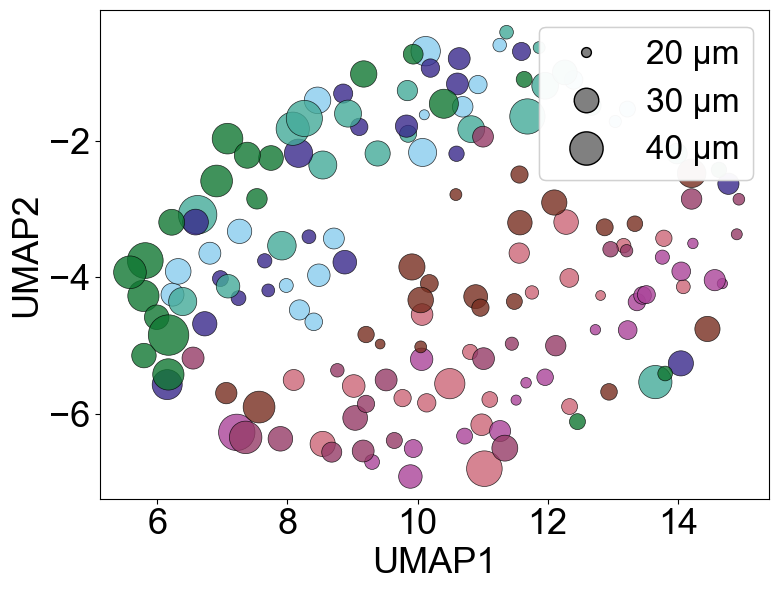

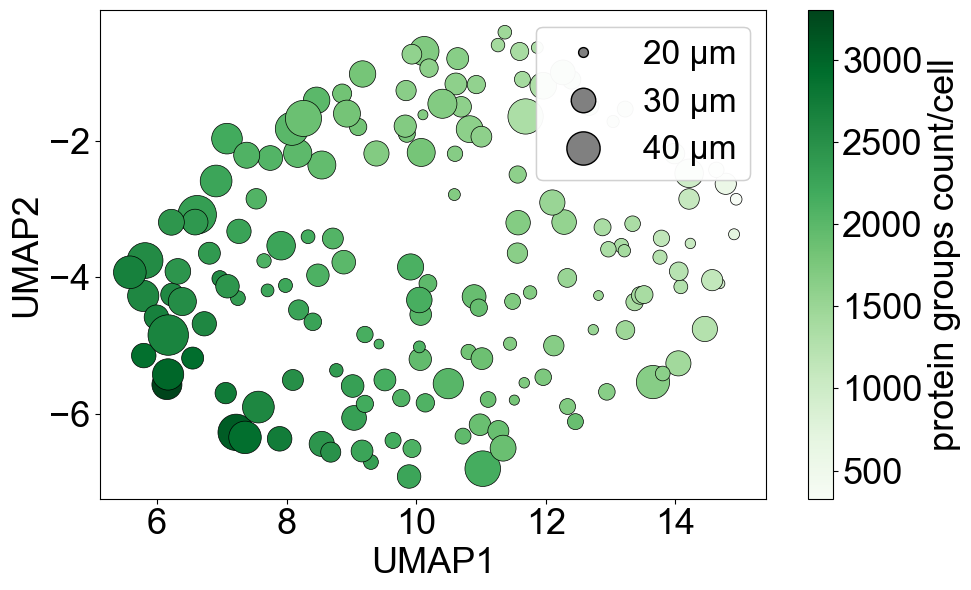

In [ ]:
diameters = pd.to_numeric(adata.obs["Diameter"], errors='coerce').fillna(0)
sizes = ((diameters - diameters.min()) / (diameters.max() - diameters.min())) * 800 + 50
sc.tl.umap(adata, random_state=42)

x = adata.obsm['X_umap'][:, 0]
y = adata.obsm['X_umap'][:, 1]  # Inverte eixo Y, se preferir visualmente

colors_condition = adata.obs["condition"].map(condition_colors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x, y,
    s=sizes,
    c=colors_condition,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.5,
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)

ref_sizes = [20, 30, 40]
scaled_ref_sizes = ((np.array(ref_sizes) - diameters.min()) / (diameters.max() - diameters.min())) * 400 + 50
ref_labels = [f"{s} µm" for s in ref_sizes]
ref_markers = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='gray', markersize=np.sqrt(scaled), label=label,
                      markeredgecolor='k') for scaled, label in zip(scaled_ref_sizes, ref_labels)]
legend1 = plt.legend(handles=ref_markers, title="", loc='upper right')
plt.gca().add_artist(legend1)

plt.tight_layout()
plt.savefig("figures/HeLa/UMAP_HeLa.svg")
plt.show()

colors_protein_count = adata.obs["protein_count"]

plt.figure(figsize=(9.9, 6))
scatter = plt.scatter(
    x, y,
    s=sizes,
    c=colors_protein_count,
    cmap="Greens",
    alpha=1,
    edgecolors='black',
    linewidths=0.5,
)

cbar = plt.colorbar(scatter)
cbar.set_label("protein groups count/cell")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)

legend2 = plt.legend(handles=ref_markers, title="", loc='upper right')
plt.gca().add_artist(legend2)

plt.tight_layout()
plt.savefig("figures/HeLa/UMAP_HeLa_Protein_Count.svg")
plt.show()

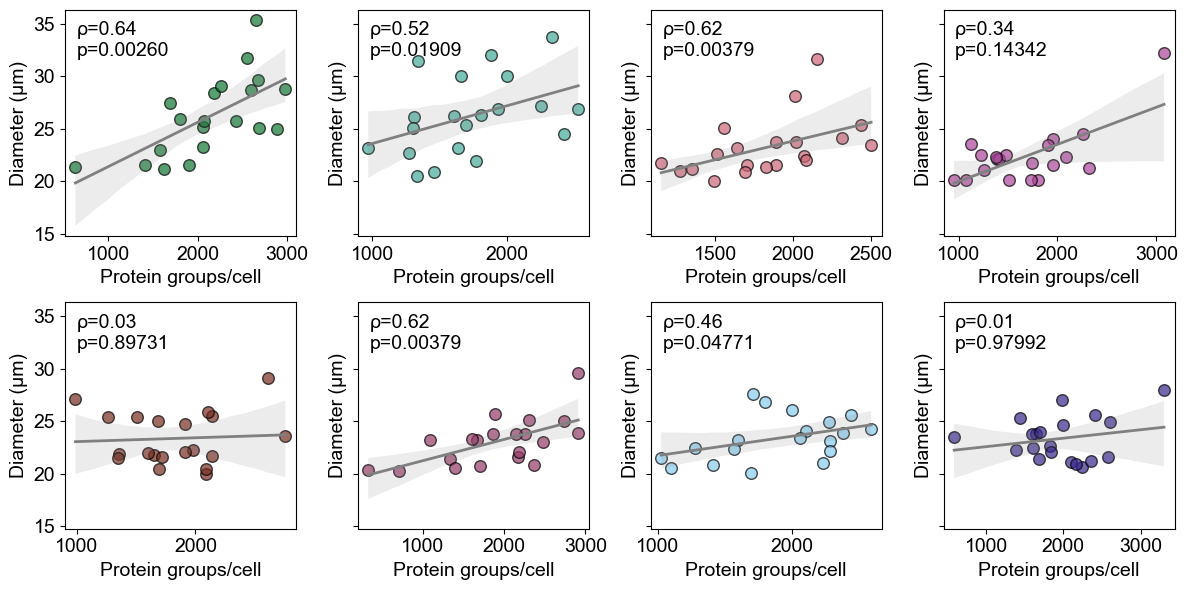

In [ ]:
diameters = pd.to_numeric(adata.obs["Diameter"], errors='coerce').fillna(0)
protein_counts = pd.to_numeric(adata.obs["protein_count"], errors='coerce').fillna(0)
conditions = adata.obs["condition"]

df = pd.DataFrame({
    "Diameter": diameters,
    "ProteinGroups": protein_counts,
    "Condition": conditions
})

condition_order = [
    "Fresh37C",
    "Fresh4C_1day",
    "PFA_15min_1day",
    "PFA_15min_8days",
    "PFA_30min_1day",
    "PFA_30min_8days",
    "Cryo-80C_1day",
    "Cryo-80C_8days"
]

fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharey=True)
axes = axes.flatten()

for ax, cond in zip(axes, condition_order):
    sub = df[df["Condition"] == cond]

    r, p = spearmanr(sub["ProteinGroups"], sub["Diameter"])

    color = condition_colors.get(cond, "gray")

    sns.regplot(
        data=sub,
        x="ProteinGroups",
        y="Diameter",
        scatter_kws={
            "s": 70,
            "alpha": 0.7,
            "edgecolor": "black",
            "color": color
        },
        line_kws={
            "color": "gray",
            "linewidth": 2
        },
        ax=ax
    )

    #ax.set_title(cond, fontsize=16, fontweight="bold")
    ax.set_xlabel("Protein groups/cell", fontsize=14)
    ax.set_ylabel("Diameter (µm)", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)

    ax.text(
        0.05, 0.95,
        f"ρ={r:.2f}\np={p:.5f}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("figures/HeLa/Correlation_CellDiameter_HeLa.svg")
plt.show()


/tmp/ipykernel_485/3686117340.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden", resolution=0.2)
/tmp/ipykernel_485/3686117340.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leiden_condition_map = adata.obs.groupby('leiden')['condition'].agg(lambda x: x.mode()[0]).to_dict()


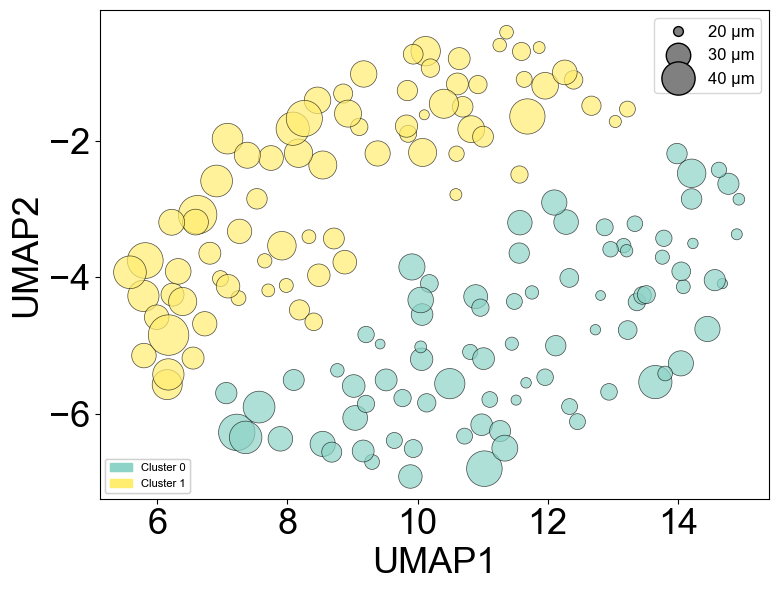

In [ ]:
sc.tl.leiden(adata, key_added="leiden", resolution=0.2)

leiden_condition_map = adata.obs.groupby('leiden')['condition'].agg(lambda x: x.mode()[0]).to_dict()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x, y,
    s=sizes,
    c=adata.obs["leiden"].astype('category').cat.codes,
    cmap="Set3",
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5,
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)

ref_sizes = [20, 30, 40]
scaled_ref_sizes = ((np.array(ref_sizes) - diameters.min()) / (diameters.max() - diameters.min())) * 400 + 50
ref_labels = [f"{s} µm" for s in ref_sizes]
ref_markers = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='gray', markersize=np.sqrt(scaled), label=label,
                      markeredgecolor='k') for scaled, label in zip(scaled_ref_sizes, ref_labels)]
legend1 = plt.legend(handles=ref_markers, title="", loc='best',  fontsize=12)
plt.gca().add_artist(legend1)

clusters = adata.obs["leiden"].astype('category').cat.categories
colors = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

patches = [mpatches.Patch(color=colors[i], label=f"Cluster {cl}")
           for i, cl in enumerate(clusters)]

legend2 = plt.legend(
    handles=patches,
    title="",
    loc='lower left',
    fontsize=8
)

plt.gca().add_artist(legend2)


plt.tight_layout()
plt.savefig("figures/HeLa/Leiden_HeLa_r0p2.svg")
plt.show()

In [ ]:
umap1 = adata.obsm["X_umap"][:, 0]
umap2 = adata.obsm["X_umap"][:, 1]

df_umap = pd.DataFrame({
    "Sample": adata.obs_names,
    "UMAP1": umap1,
    "UMAP2": umap2,
    "Leiden": adata.obs["leiden"].astype(str),
    "Condition": adata.obs["condition"].astype(str)
})

df_umap.head()

,Sample,UMAP1,UMAP2,Leiden,Condition
E:\usuarios\heloisa_prado_mas\Hela_storage_rawfiles\Raw_files\20241126_Cryo-80C_1day_A10.raw,E:\usuarios\heloisa_prado_mas\Hela_storage_raw...,8.185829,-4.479583,1,Cryo-80C_1day
E:\usuarios\heloisa_prado_mas\Hela_storage_rawfiles\Raw_files\20241126_Cryo-80C_1day_A19.raw,E:\usuarios\heloisa_prado_mas\Hela_storage_raw...,7.982843,-4.121764,1,Cryo-80C_1day
E:\usuarios\heloisa_prado_mas\Hela_storage_rawfiles\Raw_files\20241126_Cryo-80C_1day_B10.raw,E:\usuarios\heloisa_prado_mas\Hela_storage_raw...,8.483289,-3.971654,1,Cryo-80C_1day
E:\usuarios\heloisa_prado_mas\Hela_storage_rawfiles\Raw_files\20241126_Cryo-80C_1day_B19.raw,E:\usuarios\heloisa_prado_mas\Hela_storage_raw...,6.234724,-4.255934,1,Cryo-80C_1day
E:\usuarios\heloisa_prado_mas\Hela_storage_rawfiles\Raw_files\20241126_Cryo-80C_1day_C10.raw,E:\usuarios\heloisa_prado_mas\Hela_storage_raw...,8.404934,-4.653813,1,Cryo-80C_1day


In [ ]:
df_umap.to_csv("table_umap/HeLa_UMAP_coordinates_with_leiden.tsv", sep="\t", index=False)

/tmp/ipykernel_485/231310714.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_diameter_stats = adata.obs.groupby('leiden')['Diameter'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_485/231310714.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Average Diameter and Standard Deviation per Leiden Cluster:
  Leiden Cluster  Average Diameter  Diameter Std Dev
0              0         23.116145          2.609659
1              1         24.776974          3.305981


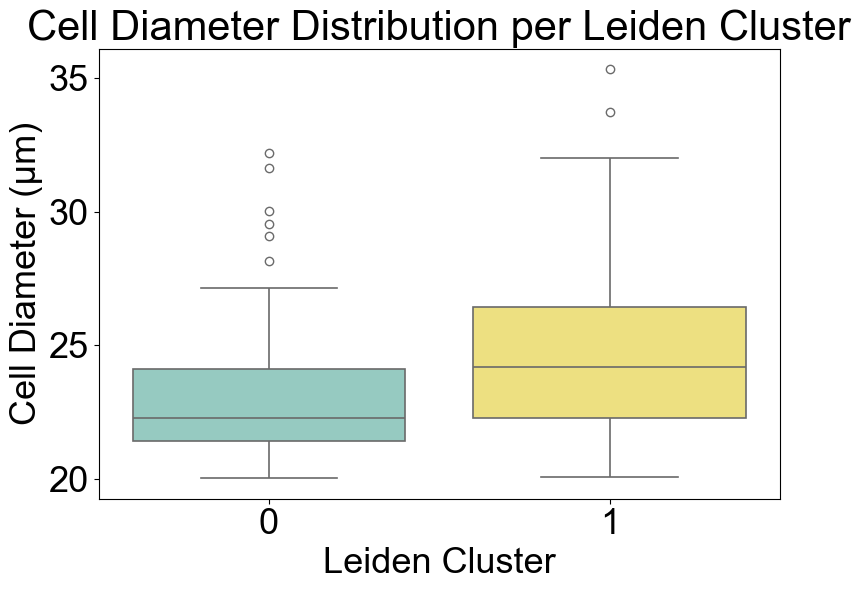

In [ ]:
cluster_diameter_stats = adata.obs.groupby('leiden')['Diameter'].agg(['mean', 'std']).reset_index()
cluster_diameter_stats.columns = ['Leiden Cluster', 'Average Diameter', 'Diameter Std Dev']

print("Average Diameter and Standard Deviation per Leiden Cluster:")
print(cluster_diameter_stats)

clusters = adata.obs["leiden"].astype('category').cat.categories
colors = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

cluster_colors = dict(zip(clusters, colors))

plt.figure(figsize=(8, 6))
sns.boxplot(
    x='leiden',
    y='Diameter',
    data=adata.obs,
    palette=cluster_colors,
    linewidth=1.2
)

plt.xlabel("Leiden Cluster")
plt.ylabel("Cell Diameter (µm)")
plt.title("Cell Diameter Distribution per Leiden Cluster")
plt.grid(False)
plt.tight_layout()
plt.savefig("figures/HeLa/Boxplot_HeLa_morphometrics.svg", dpi=300)
plt.show()


In [ ]:
groups = [
    adata.obs.loc[adata.obs["leiden"] == cluster, "Diameter"].dropna()
    for cluster in adata.obs["leiden"].unique()
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H = {stat:.3f}")
print(f"p-value = {p_value:.3e}")

Kruskal-Wallis H = 12.443
p-value = 4.195e-04


In [ ]:
df_stats = adata.obs[["leiden", "Diameter"]].dropna()

dunn_results = sp.posthoc_dunn(
    df_stats,
    val_col="Diameter",
    group_col="leiden",
    p_adjust="fdr_bh"
)

print(dunn_results)

         0        1
0  1.00000  0.00042
1  0.00042  1.00000


['1', '0']
Categories (2, object): ['0', '1']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.223e-04 U_stat=2.131e+03


/tmp/ipykernel_485/538344305.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


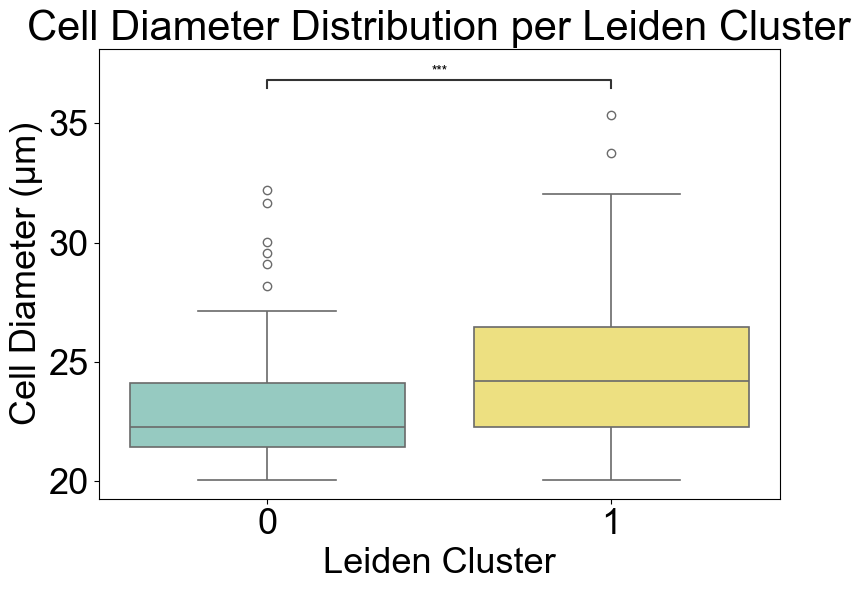

In [ ]:
print(adata.obs["leiden"].unique())

pairs = [
    ("0", "1")
]

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="leiden",
    y="Diameter",
    data=adata.obs,
    palette=cluster_colors,
    linewidth=1.2
)

annotator = Annotator(
    ax,
    pairs,
    data=adata.obs,
    x="leiden",
    y="Diameter"
)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    comparisons_correction="fdr_bh"
)
annotator.apply_and_annotate()

plt.xlabel("Leiden Cluster")
plt.ylabel("Cell Diameter (µm)")
plt.title("Cell Diameter Distribution per Leiden Cluster")
plt.tight_layout()
plt.savefig(
    "figures/HeLa/Boxplot_HeLa_morphometrics_stats.svg",
    dpi=300
)
plt.show()

In [ ]:
groups = [
    adata.obs.loc[adata.obs["condition"] == cluster, "Diameter"].dropna()
    for cluster in adata.obs["condition"].unique()
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H = {stat:.3f}")
print(f"p-value = {p_value:.3e}")

Kruskal-Wallis H = 26.862
p-value = 3.528e-04


In [ ]:
df_stats = adata.obs[["condition", "Diameter"]].dropna()

dunn_results = sp.posthoc_dunn(
    df_stats,
    val_col="Diameter",
    group_col="condition",
    p_adjust="fdr_bh"
)

print(dunn_results)

                 Cryo-80C_1day  Cryo-80C_8days  Fresh37C  Fresh4C_1day  \
Cryo-80C_1day         1.000000        0.963074  0.055768      0.051116   
Cryo-80C_8days        0.963074        1.000000  0.051116      0.050712   
Fresh37C              0.055768        0.051116  1.000000      0.963074   
Fresh4C_1day          0.051116        0.050712  0.963074      1.000000   
PFA_15min_1day        0.880342        0.880342  0.025783      0.025783   
PFA_15min_8days       0.248715        0.248715  0.001512      0.001512   
PFA_30min_1day        0.963074        0.963074  0.050451      0.047785   
PFA_30min_8days       0.880342        0.880342  0.025783      0.025783   

                 PFA_15min_1day  PFA_15min_8days  PFA_30min_1day  \
Cryo-80C_1day          0.880342         0.248715        0.963074   
Cryo-80C_8days         0.880342         0.248715        0.963074   
Fresh37C               0.025783         0.001512        0.050451   
Fresh4C_1day           0.025783         0.001512        0.047

In [ ]:
cluster_colors = {
    "Fresh37C": "#107732",
    "Fresh4C_1day": "#44aa99",
    "PFA_15min_1day": "#cc6677",
    "PFA_15min_8days": "#aa4499",
    "PFA_30min_1day": "#772d1f",
    "PFA_30min_8days": "#953b67",
    "Cryo-80C_1day": "#88ccee",
    "Cryo-80C_8days": "#38288b"
}

['Cryo-80C_1day' 'Cryo-80C_8days' 'Fresh4C_1day' 'Fresh37C'
 'PFA_15min_1day' 'PFA_15min_8days' 'PFA_30min_1day' 'PFA_30min_8days']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fresh37C vs. Fresh4C_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:9.031e-01 U_stat=1.950e+02
Fresh37C vs. Cryo-80C_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.289e-02 U_stat=2.790e+02
Fresh37C vs. Cryo-80C_8days: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.111e-03 U_stat=3.000e+02
Fresh37C vs. PFA_15min_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.038e-03 U_stat=3.020e+02
Fresh37C vs. PFA_15min_8days: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.860e-04 U_stat=3.260e+02
Fre

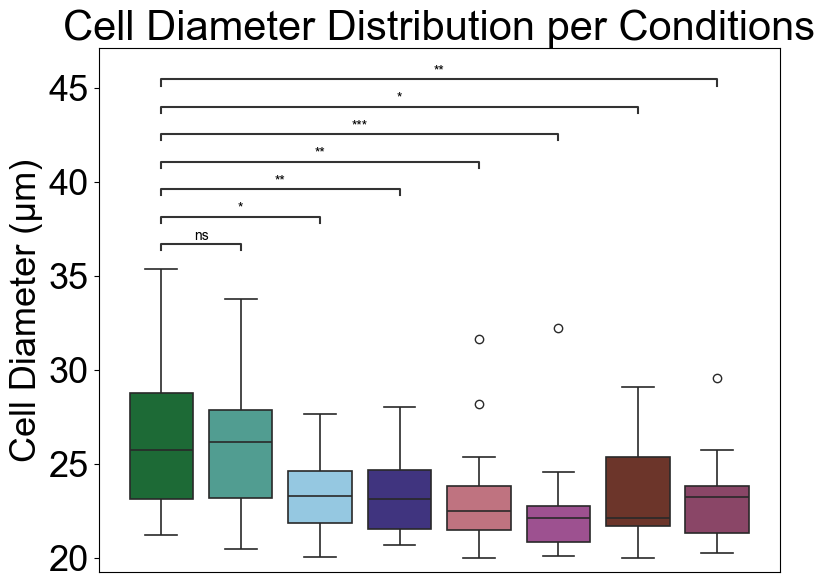

In [ ]:
print(adata.obs["condition"].unique())

order = [
    "Fresh37C",
    "Fresh4C_1day",
    "Cryo-80C_1day",
    "Cryo-80C_8days",
    "PFA_15min_1day",
    "PFA_15min_8days",
    "PFA_30min_1day",
    "PFA_30min_8days"
]

pairs = [
    ("Fresh37C", "Fresh4C_1day"),
    ("Fresh37C", "Cryo-80C_1day"),
    ("Fresh37C", "Cryo-80C_8days"),
    ("Fresh37C", "PFA_15min_1day"),
    ("Fresh37C", "PFA_15min_8days"),
    ("Fresh37C", "PFA_30min_1day"),
    ("Fresh37C", "PFA_30min_8days"),
]

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="condition",
    y="Diameter",
    data=adata.obs,
    order=order,
    hue="condition",
    palette=cluster_colors,
    linewidth=1.2,
    legend=False
)

annotator = Annotator(
    ax,
    pairs,
    data=adata.obs,
    x="condition",
    y="Diameter",
    order=order
)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    comparisons_correction="fdr_bh"
)
annotator.apply_and_annotate()

ax.set_xlabel("")
ax.set_xticklabels([])
ax.tick_params(axis="x", bottom=False)

plt.ylabel("Cell Diameter (µm)")
plt.title("Cell Diameter Distribution per Conditions")
plt.tight_layout()
plt.savefig(
    "figures/HeLa/Boxplot_HeLa_morphometrics_diameter_stats.svg",
    dpi=300
)
plt.show()

In [ ]:
valid_samples = [sample for sample in transposed_data.index if "_" in sample]
condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return None

sample_conditions = [extract_condition(row) for row in transposed_data.index]

unmatched_conditions = [row for row, condition in zip(transposed_data.index, sample_conditions) if condition is None]
if unmatched_conditions:
    print("Amostras sem correspondência de condição:", unmatched_conditions)

colors = [condition_colors.get(condition, "#000000") for condition in sample_conditions]

adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs["condition"] = sample_conditions
adata.var_names = transposed_data.columns

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=20)

sc.pp.neighbors(adata)

sc.tl.umap(adata)
sc.tl.umap(adata, random_state=42)

sc.tl.leiden(adata, resolution=0.2)

/tmp/ipykernel_485/2761935859.py:31: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.2)


In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden",
    pts=True,
    pts_rest=True
)

In [ ]:
marker_genes = []
all_markers = []
groups = adata.obs["leiden"].unique().tolist()

X = adata.X

for group in groups:
    print(f"Processando cluster {group}...")

    df = sc.get.rank_genes_groups_df(adata, group=group, key="dea_leiden")
    df = df.dropna(subset=["logfoldchanges", "pvals_adj"])

    genes = df["names"].values

    idx_in = adata.obs["leiden"] == group
    X_in = X[idx_in, :]

    idx_out = adata.obs["leiden"] != group
    X_out = X[idx_out, :]

    pct_in = []
    pct_out = []

    for g in genes:
        gene_idx = adata.var_names.get_loc(g)

        if hasattr(X_in, "A"):
            pct_in_val = (X_in[:, gene_idx].A > 0).mean()
            pct_out_val = (X_out[:, gene_idx].A > 0).mean()
        else:
            pct_in_val = (X_in[:, gene_idx] > 0).mean()
            pct_out_val = (X_out[:, gene_idx] > 0).mean()

        pct_in.append(pct_in_val)
        pct_out.append(pct_out_val)

    df = df.copy()
    df["pct_in"] = pct_in
    df["pct_out"] = pct_out

    df_filtered = df[
        (df["pvals_adj"] < 0.05) &
        (df["logfoldchanges"] > 1) &
        (df["pct_in"] > 0.6) &
        (df["pct_out"] < 0.2)
    ]

    marker_genes.extend(df_filtered["names"].tolist())

    df_filtered["cluster"] = group
    all_markers.append(df_filtered)

final_df = pd.concat(all_markers, ignore_index=True)

marker_genes = list(dict.fromkeys(marker_genes))

print(marker_genes)

final_df.to_csv("table_markers/HeLa_leiden_marker_genes_with_pct.tsv", sep="\t", index=False)

Processando cluster 1...
Processando cluster 0...
['APRT', 'CRK', 'PPP1R14B', 'GLOD4', 'ARL3', 'NUDT1', 'PGAM1', 'UBA6', 'PEA15', 'RHEB', 'IL18', 'TYMS', 'DDAH1', 'CBR3', 'CFL2', 'UBE2R2', 'GFUS', 'PGLS', 'XPNPEP1', 'THOP1', 'DDT', 'PTRHD1', 'PCYT2', 'NAPRT', 'GSTM1', 'PPP5C', 'MIF', 'GDI1', 'DAP', 'NT5DC1', 'QDPR', 'GSDME', 'UBA3']


/tmp/ipykernel_485/362644237.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["cluster"] = group


Calculando pct_in e pct_out...
Genes após filtragem: 33
Exclusive selected (top by logFC):
{'1': ['APRT', 'PPP1R14B', 'IL18', 'NUDT1', 'GLOD4', 'DDT', 'PGAM1', 'PGLS', 'DDAH1', 'PEA15']}


/tmp/ipykernel_485/429253904.py:73: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


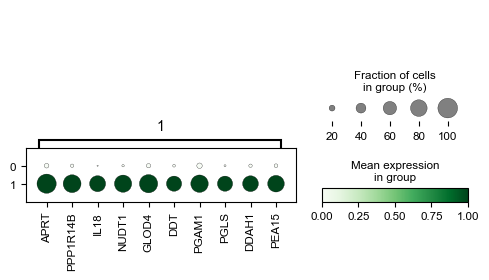

In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df = full_df[full_df["pvals_adj"] < 0.05]

print("Calculando pct_in e pct_out...")

X = adata.X
groups = adata.obs["leiden"].unique().tolist()

pct_in_list = []
pct_out_list = []

for idx, row in full_df.iterrows():
    gene = row["names"]
    group = row["group"]

    gene_idx = adata.var_names.get_loc(gene)

    idx_in = adata.obs["leiden"] == group
    idx_out = adata.obs["leiden"] != group

    X_in = X[idx_in, gene_idx]
    X_out = X[idx_out, gene_idx]

    if hasattr(X_in, "A"):
        pct_in = (X_in.A > 0).mean()
        pct_out = (X_out.A > 0).mean()
    else:
        pct_in = (X_in > 0).mean()
        pct_out = (X_out > 0).mean()

    pct_in_list.append(pct_in)
    pct_out_list.append(pct_out)

full_df["pct_in"] = pct_in_list
full_df["pct_out"] = pct_out_list


filtered_df = full_df[
    (full_df["logfoldchanges"] > 1) &
    (full_df["pct_in"] > 0.6) &
    (full_df["pct_out"] < 0.2)
]

print("Genes após filtragem:", filtered_df.shape[0])

exclusive_genes = {}

for group in groups:
    cluster_df = filtered_df[filtered_df["group"] == group]

    cluster_genes = set(cluster_df["names"])
    other_genes = set(filtered_df[filtered_df["group"] != group]["names"])
    exclusive = cluster_genes - other_genes

    df = cluster_df[cluster_df["names"].isin(exclusive)]
    df = df.sort_values("logfoldchanges", ascending=False).head(10)

    if not df.empty:
        exclusive_genes[group] = df["names"].tolist()

print("Exclusive selected (top by logFC):")
print(exclusive_genes)

adata.var_names_make_unique()

sc.pl.dotplot(
    adata,
    var_names=exclusive_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="Greens",
    dendrogram=True,
    show=True,
    save="HeLa_PG_dotplot.svg"
)

!mv figures/dotplot_HeLa_PG_dotplot.svg figures/HeLa/

/tmp/ipykernel_485/3447091465.py:5: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


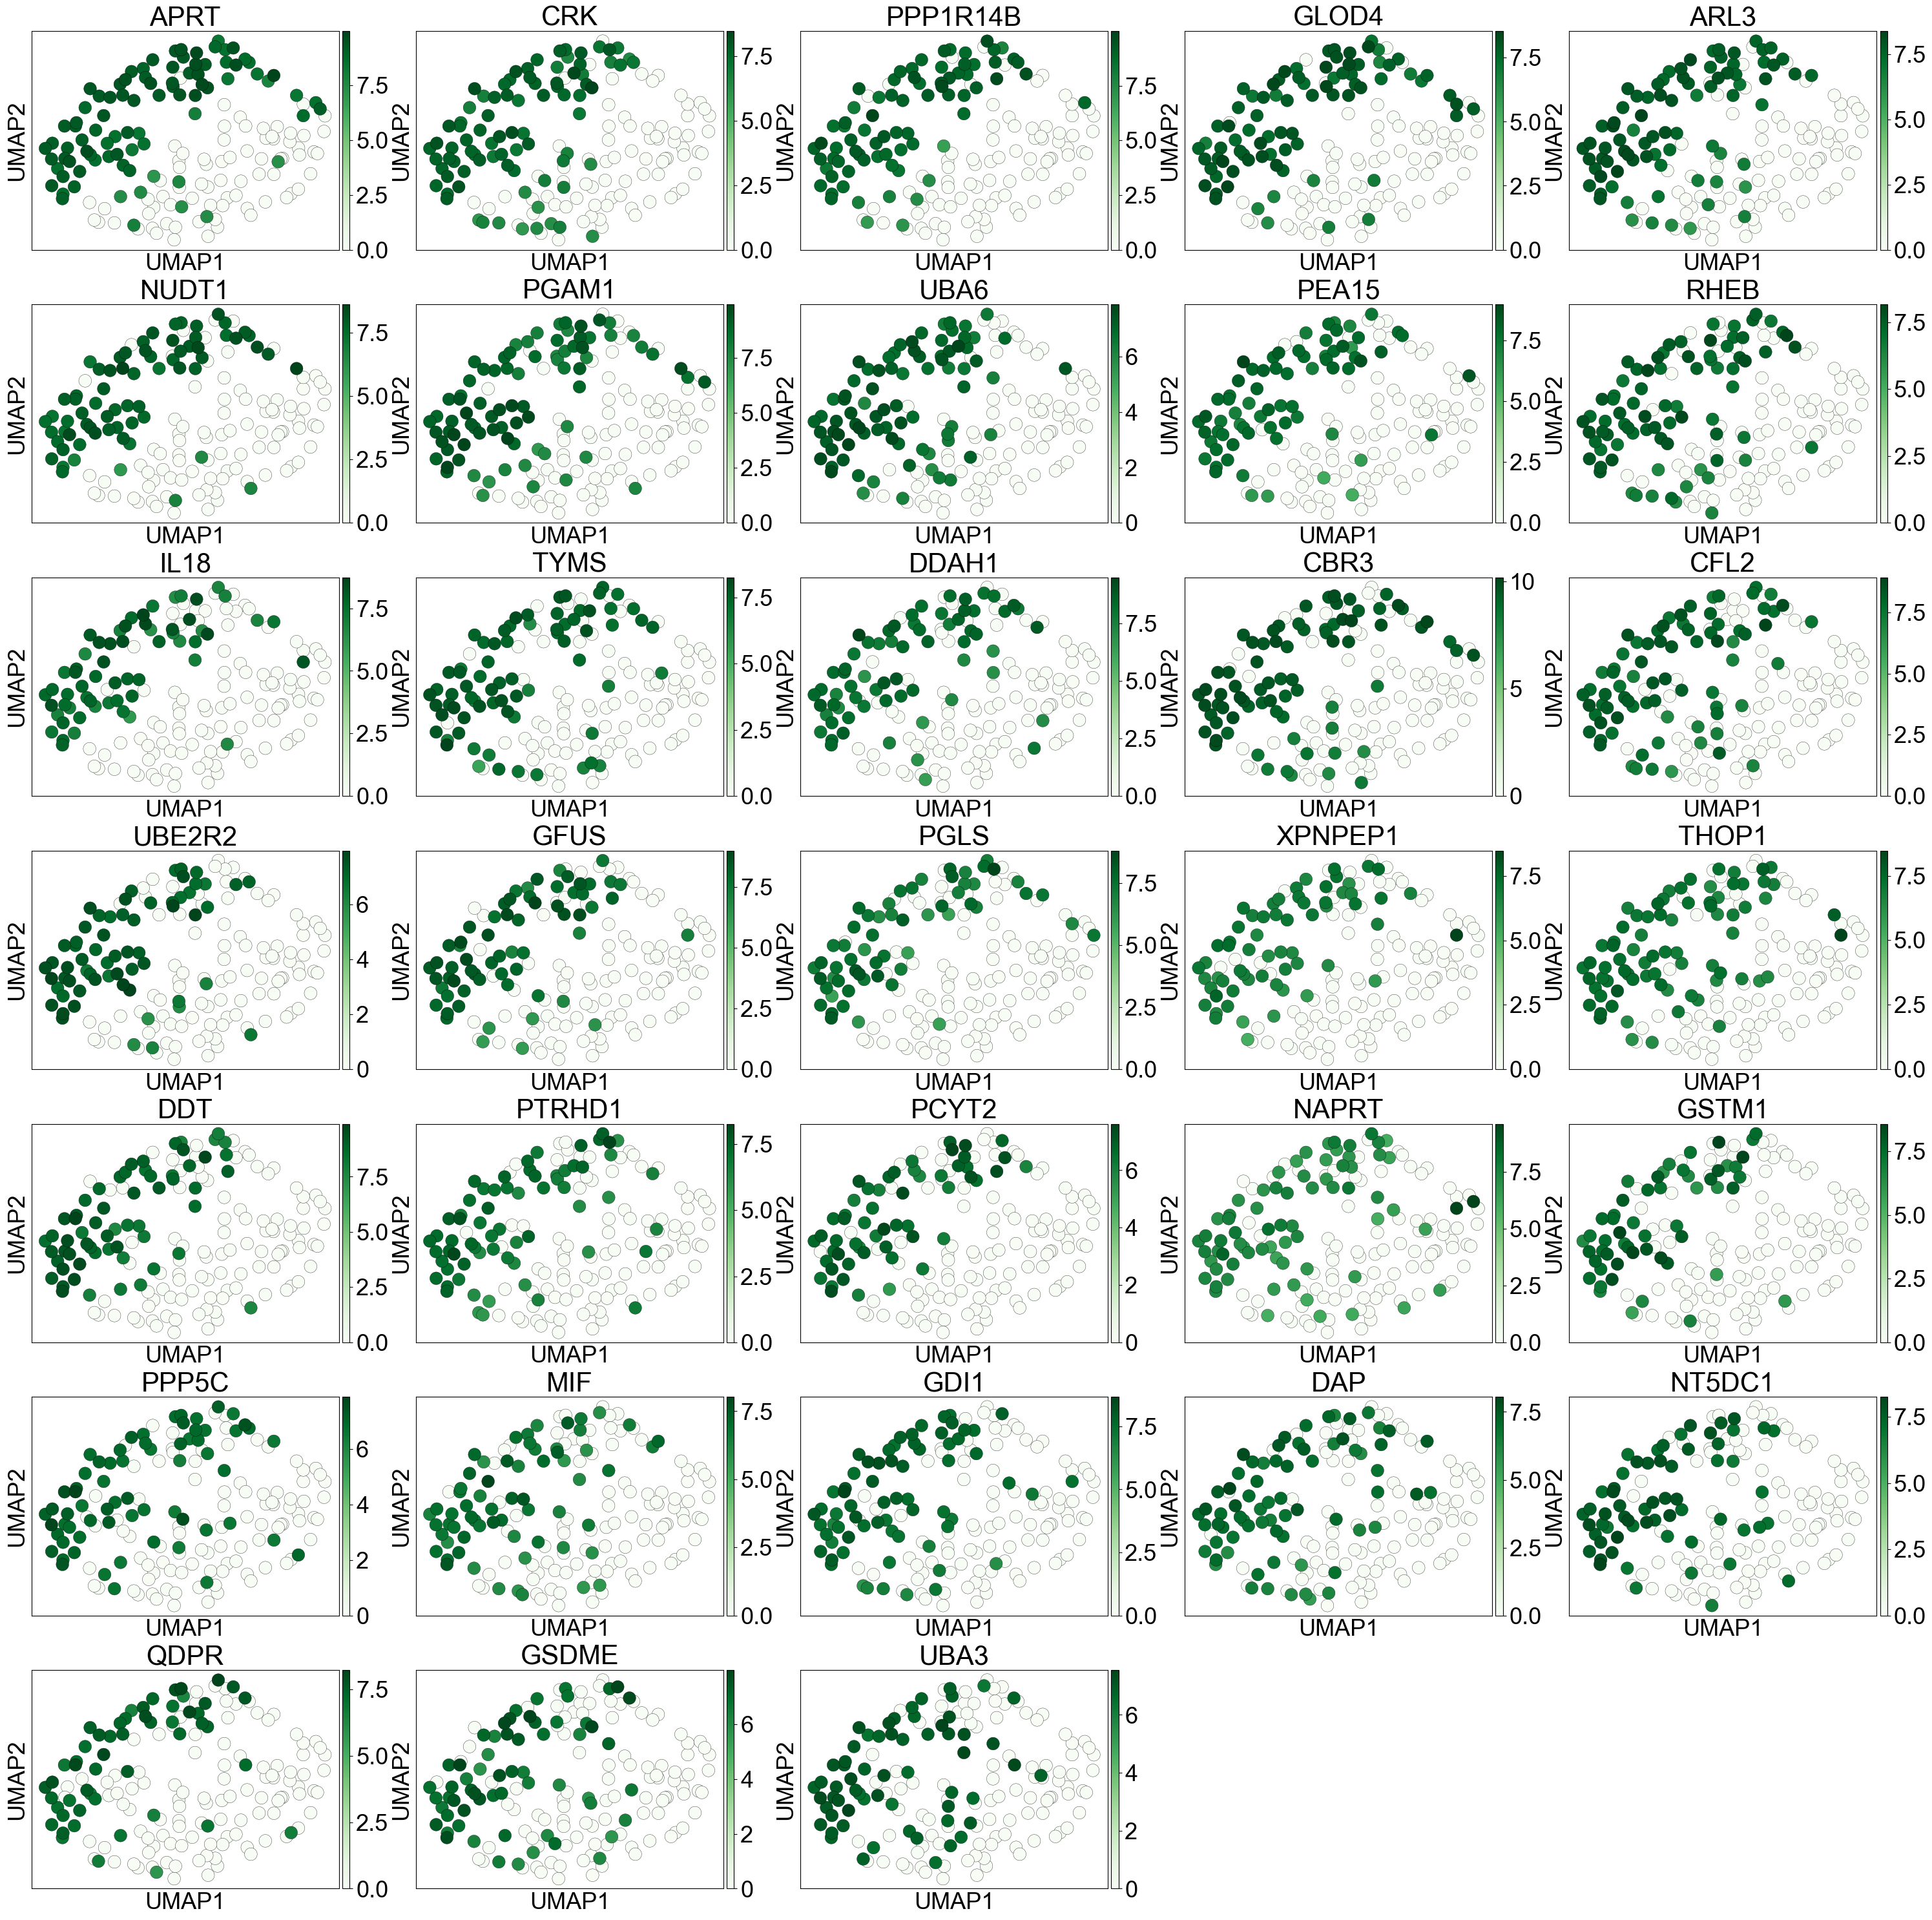

In [ ]:
adata.var_names_make_unique()

present_genes = [gene for gene in marker_genes if gene in adata.var_names]

sc.pl.umap(
    adata,
    color=present_genes,
    cmap="Greens",
    size=800,
    linewidth=0.25,
    edgecolor='black',
    ncols=5,
    save="_PG_UMAP_highlight_leiden_selected_genes.svg"
)

!mv figures/umap_PG_UMAP_highlight_leiden_selected_genes.svg figures/HeLa/

In [ ]:
valid_marker_genes = [pg for pg in marker_genes if pg in adata.var_names]
expr_matrix = adata[:, valid_marker_genes].to_df()
expr_matrix = (expr_matrix - expr_matrix.mean()) / expr_matrix.std()
expr_matrix = expr_matrix.T

leiden_labels = adata.obs["leiden"].astype(str)
n_clusters = len(leiden_labels.unique())
leiden_colors = cm.get_cmap('Set3', n_clusters).colors
leiden_color_dict = dict(zip(sorted(leiden_labels.unique()), leiden_colors))
leiden_col = leiden_labels.map(leiden_color_dict)

condition_labels = adata.obs["condition"].astype(str)

condition_colors = {
    "Fresh37C": "#107732",
    "Fresh4C_1day": "#44aa99",
    "PFA_15min_1day": "#cc6677",
    "PFA_15min_8days": "#aa4499",
    "PFA_30min_1day": "#772d1f",
    "PFA_30min_8days": "#953b67",
    "Cryo-80C_1day": "#88ccee",
    "Cryo-80C_8days": "#38288b",
}

condition_col = condition_labels.map(condition_colors)

col_colors = pd.concat([leiden_col, condition_col], axis=1)
col_colors.columns = ["Leiden", "Condition"]

/tmp/ipykernel_485/2467891813.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  leiden_colors = cm.get_cmap('Set3', n_clusters).colors


In [ ]:
morpho = pd.read_excel("morphometrics_HeLa.xlsx")

print(morpho.head())
print(morpho.columns)
print(morpho.shape)

  Well         Sample  Diameter  Elongation  Circularity
0  A10  Cryo-80C_1day     23.10        1.44         1.03
1  A19  Cryo-80C_1day     21.01        1.54         1.05
2  B10  Cryo-80C_1day     24.09        1.49         1.04
3  B19  Cryo-80C_1day     24.30        1.29         1.02
4  C10  Cryo-80C_1day     22.15        1.70         1.07
Index(['Well', 'Sample', 'Diameter', 'Elongation', 'Circularity'], dtype='object')
(159, 5)


In [ ]:
adata.obs["Diameter"] = morpho["Diameter"].values
adata.obs["Elongation"] = morpho["Elongation"].values
adata.obs["Circularity"] = morpho["Circularity"].values

In [ ]:
diam_norm = (adata.obs["Diameter"] - adata.obs["Diameter"].min()) / \
            (adata.obs["Diameter"].max() - adata.obs["Diameter"].min())

elong_norm = (adata.obs["Elongation"] - adata.obs["Elongation"].min()) / \
             (adata.obs["Elongation"].max() - adata.obs["Elongation"].min())

circ_norm = (adata.obs["Circularity"] - adata.obs["Circularity"].min()) / \
            (adata.obs["Circularity"].max() - adata.obs["Circularity"].min())

diam_col = [cm.Oranges(v) for v in diam_norm]
elong_col = [cm.Greens(v) for v in elong_norm]
circ_col = [cm.Blues(v) for v in circ_norm]

col_colors = pd.concat(
    [
        leiden_col,
        condition_col,
        pd.Series(diam_col, index=adata.obs.index, name="diameter"),
        pd.Series(elong_col, index=adata.obs.index, name="elongation"),
        pd.Series(circ_col, index=adata.obs.index, name="circularity")
    ],
    axis=1
)

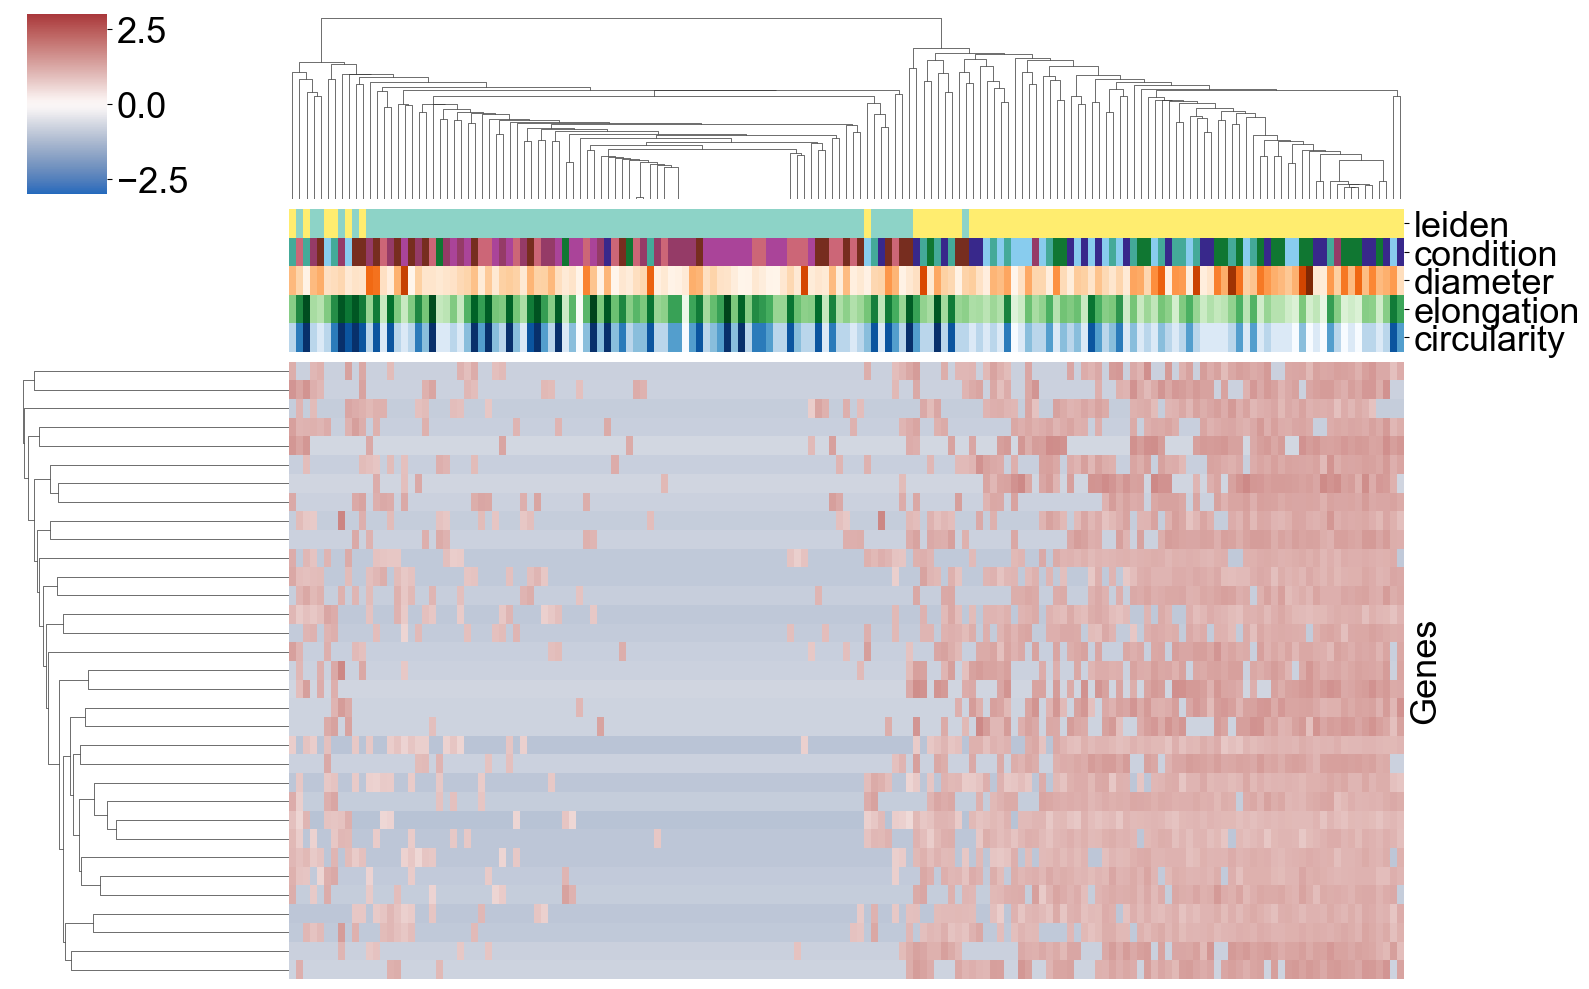

In [ ]:
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)

sns.clustermap(
    expr_matrix,
    cmap="vlag",
    norm=norm,
    figsize=(16, 10),
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=False,
    metric="euclidean",
    method="average",
    dendrogram_ratio=0.2
)

plt.savefig("figures/HeLa/Heatmap_HeLa_topmarkers.svg", dpi=300)
plt.show()


/tmp/ipykernel_485/3926861945.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden")[["Diameter", "Elongation"]]
/tmp/ipykernel_485/3926861945.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Average morphometrics per Leiden Cluster:
  Leiden Cluster  Average Diameter  Diameter Std Dev  Average Elongation  \
0              0         23.116145          2.609659            1.527229   
1              1         24.776974          3.305981            1.433421   

   Elongation Std Dev  
0            0.156901  
1            0.131560  


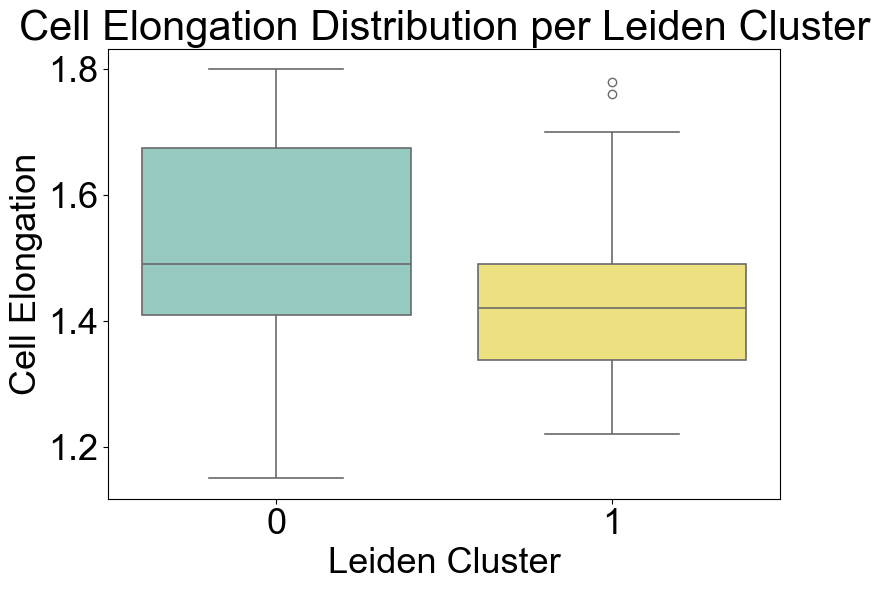

In [ ]:
cluster_morpho_stats = (
    adata.obs
    .groupby("leiden")[["Diameter", "Elongation"]]
    .agg(["mean", "std"])
    .reset_index()
)

cluster_morpho_stats.columns = [
    "Leiden Cluster",
    "Average Diameter", "Diameter Std Dev",
    "Average Elongation", "Elongation Std Dev"
]

print("Average morphometrics per Leiden Cluster:")
print(cluster_morpho_stats)
clusters = adata.obs["leiden"].astype("category").cat.categories
colors = plt.cm.Set3(np.linspace(0, 1, len(clusters)))
cluster_colors = dict(zip(clusters, colors))
plt.figure(figsize=(8, 6))
sns.boxplot(
    x="leiden",
    y="Elongation",
    data=adata.obs,
    palette=cluster_colors,
    linewidth=1.2
)

plt.xlabel("Leiden Cluster")
plt.ylabel("Cell Elongation")
plt.title("Cell Elongation Distribution per Leiden Cluster")
plt.grid(False)
plt.tight_layout()
plt.savefig("figures/HeLa/Boxplot_HeLa_elongation.svg", dpi=300)
plt.show()


In [ ]:
groups_elong = [
    adata.obs.loc[adata.obs["leiden"] == cluster, "Elongation"].dropna()
    for cluster in adata.obs["leiden"].unique()
]

stat, p_value = kruskal(*groups_elong)

print(f"Kruskal-Wallis H (Elongation) = {stat:.3f}")
print(f"p-value = {p_value:.3e}")


Kruskal-Wallis H (Elongation) = 15.520
p-value = 8.166e-05


In [ ]:
df_stats_elong = adata.obs[["leiden", "Elongation"]].dropna()

dunn_results_elong = sp.posthoc_dunn(
    df_stats_elong,
    val_col="Elongation",
    group_col="leiden",
    p_adjust="fdr_bh"
)

print(dunn_results_elong)

          0         1
0  1.000000  0.000082
1  0.000082  1.000000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:8.225e-05 U_stat=4.296e+03


/tmp/ipykernel_485/2234505011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


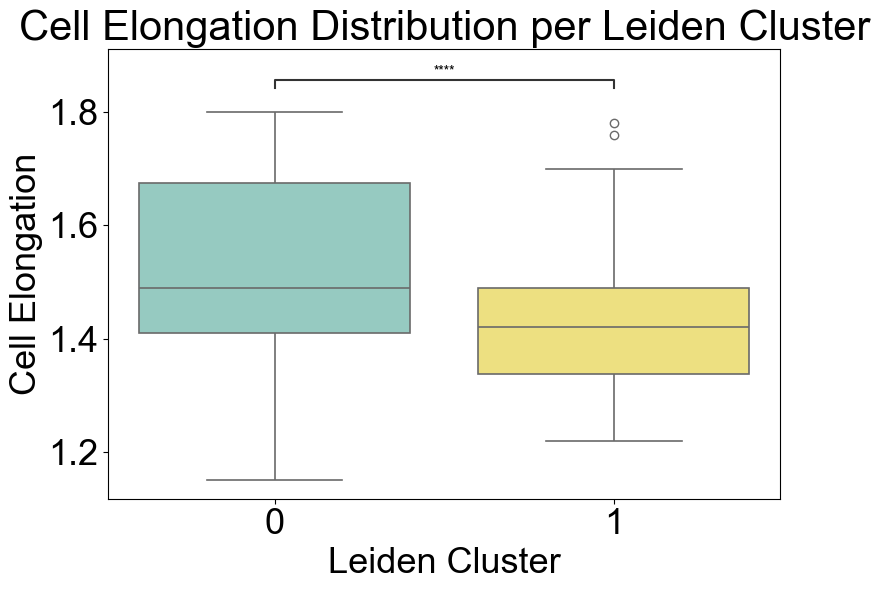

In [ ]:
pairs = [
    ("0", "1")
]

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="leiden",
    y="Elongation",
    data=adata.obs,
    palette=cluster_colors,
    linewidth=1.2
)

annotator = Annotator(
    ax,
    pairs,
    data=adata.obs,
    x="leiden",
    y="Elongation"
)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    comparisons_correction="fdr_bh"
)
annotator.apply_and_annotate()

plt.xlabel("Leiden Cluster")
plt.ylabel("Cell Elongation")
plt.title("Cell Elongation Distribution per Leiden Cluster")
plt.tight_layout()
plt.savefig(
    "figures/HeLa/Boxplot_HeLa_elongation_stats.svg",
    dpi=300
)
plt.show()


In [ ]:
groups_elong = [
    adata.obs.loc[adata.obs["leiden"] == cluster, "Circularity"].dropna()
    for cluster in adata.obs["leiden"].unique()
]

stat, p_value = kruskal(*groups_elong)

print(f"Kruskal-Wallis H (Circularity) = {stat:.3f}")
print(f"p-value = {p_value:.3e}")


Kruskal-Wallis H (Circularity) = 14.340
p-value = 1.525e-04


In [ ]:
df_stats_elong = adata.obs[["leiden", "Circularity"]].dropna()

dunn_results_elong = sp.posthoc_dunn(
    df_stats_elong,
    val_col="Circularity",
    group_col="leiden",
    p_adjust="fdr_bh"
)

print(dunn_results_elong)

          0         1
0  1.000000  0.000153
1  0.000153  1.000000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.536e-04 U_stat=4.234e+03


/tmp/ipykernel_485/3300937190.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


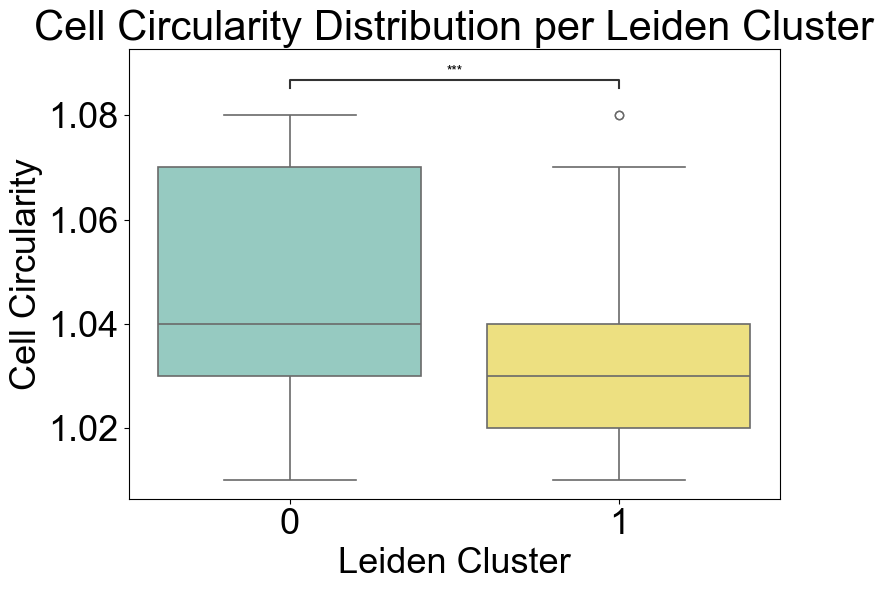

In [ ]:
pairs = [
    ("0", "1")
]

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="leiden",
    y="Circularity",
    data=adata.obs,
    palette=cluster_colors,
    linewidth=1.2
)

annotator = Annotator(
    ax,
    pairs,
    data=adata.obs,
    x="leiden",
    y="Circularity"
)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    comparisons_correction="fdr_bh"
)
annotator.apply_and_annotate()

plt.xlabel("Leiden Cluster")
plt.ylabel("Cell Circularity")
plt.title("Cell Circularity Distribution per Leiden Cluster")
plt.tight_layout()
plt.savefig(
    "figures/HeLa/Boxplot_HeLa_Circularity_stats.svg",
    dpi=300
)
plt.show()


In [ ]:
cluster_colors = {
    "Fresh37C": "#107732",
    "Fresh4C_1day": "#44aa99",
    "PFA_15min_1day": "#cc6677",
    "PFA_15min_8days": "#aa4499",
    "PFA_30min_1day": "#772d1f",
    "PFA_30min_8days": "#953b67",
    "Cryo-80C_1day": "#88ccee",
    "Cryo-80C_8days": "#38288b"
}

['Cryo-80C_1day', 'Cryo-80C_8days', 'Fresh4C_1day', 'Fresh37C', 'PFA_15min_1day', 'PFA_15min_8days', 'PFA_30min_1day', 'PFA_30min_8days']
Categories (8, object): ['Cryo-80C_1day', 'Cryo-80C_8days', 'Fresh4C_1day', 'Fresh37C',
                         'PFA_15min_1day', 'PFA_15min_8days', 'PFA_30min_1day', 'PFA_30min_8days']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fresh37C vs. Fresh4C_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.354e-05 U_stat=4.850e+01
Fresh37C vs. Cryo-80C_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.425e-02 U_stat=1.180e+02
Fresh37C vs. Cryo-80C_8days: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.803e-02 U_stat=1.265e+02
Fresh37C vs. PFA_15min_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-

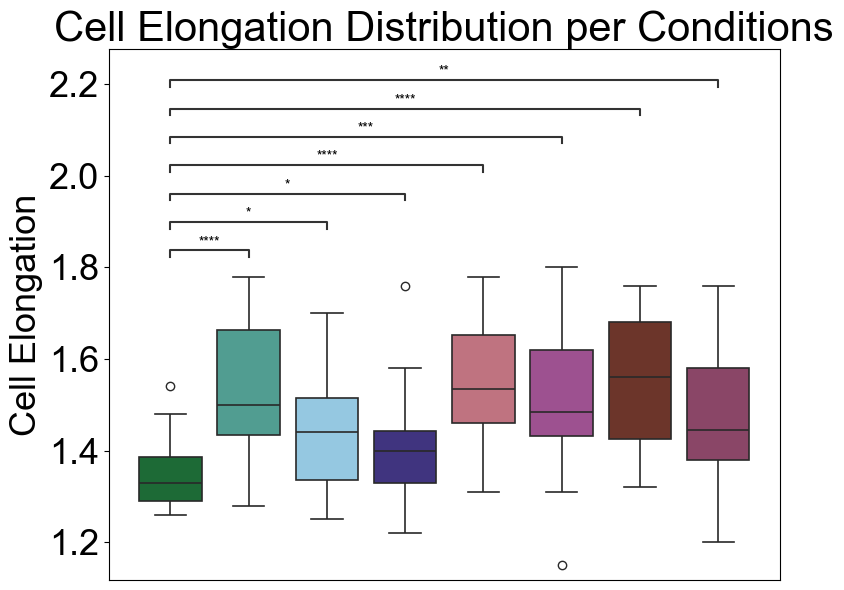

In [ ]:
print(adata.obs["condition"].unique())

order = [
    "Fresh37C",
    "Fresh4C_1day",
    "Cryo-80C_1day",
    "Cryo-80C_8days",
    "PFA_15min_1day",
    "PFA_15min_8days",
    "PFA_30min_1day",
    "PFA_30min_8days"
]

pairs = [
    ("Fresh37C", "Fresh4C_1day"),
    ("Fresh37C", "Cryo-80C_1day"),
    ("Fresh37C", "Cryo-80C_8days"),
    ("Fresh37C", "PFA_15min_1day"),
    ("Fresh37C", "PFA_15min_8days"),
    ("Fresh37C", "PFA_30min_1day"),
    ("Fresh37C", "PFA_30min_8days"),
]

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="condition",
    y="Elongation",
    data=adata.obs,
    order=order,
    hue="condition",
    palette=cluster_colors,
    linewidth=1.2,
    legend=False
)

annotator = Annotator(
    ax,
    pairs,
    data=adata.obs,
    x="condition",
    y="Elongation",
    order=order
)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    comparisons_correction="fdr_bh"
)
annotator.apply_and_annotate()

ax.set_xlabel("")
ax.set_xticklabels([])
ax.tick_params(axis="x", bottom=False)

plt.ylabel("Cell Elongation")
plt.title("Cell Elongation Distribution per Conditions")
plt.tight_layout()
plt.savefig(
    "figures/HeLa/Boxplot_HeLa_morphometrics_elongation_stats.svg",
    dpi=300
)
plt.show()

['Cryo-80C_1day', 'Cryo-80C_8days', 'Fresh4C_1day', 'Fresh37C', 'PFA_15min_1day', 'PFA_15min_8days', 'PFA_30min_1day', 'PFA_30min_8days']
Categories (8, object): ['Cryo-80C_1day', 'Cryo-80C_8days', 'Fresh4C_1day', 'Fresh37C',
                         'PFA_15min_1day', 'PFA_15min_8days', 'PFA_30min_1day', 'PFA_30min_8days']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fresh37C vs. Fresh4C_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.217e-05 U_stat=4.600e+01
Fresh37C vs. Cryo-80C_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.134e-02 U_stat=1.260e+02
Fresh37C vs. Cryo-80C_8days: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.030e-02 U_stat=1.365e+02
Fresh37C vs. PFA_15min_1day: Mann-Whitney-Wilcoxon test two-sided with Benjamini-

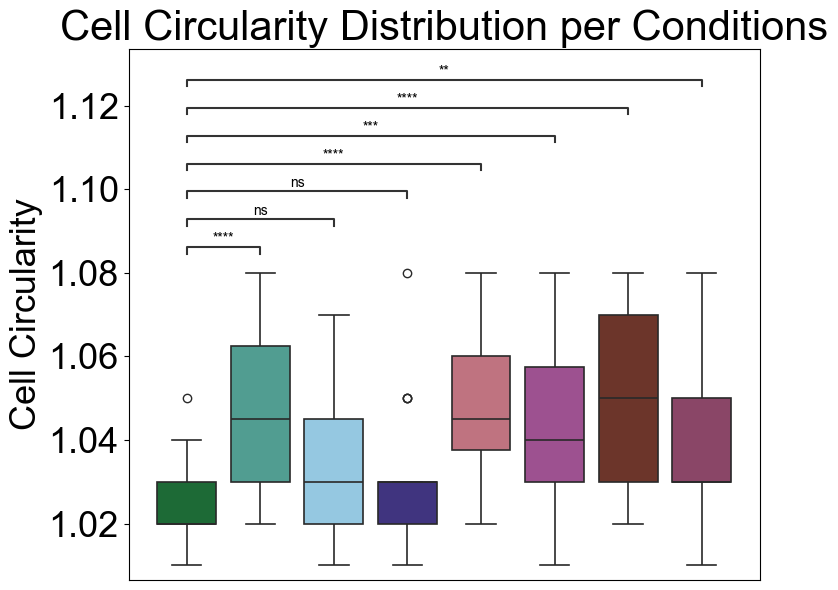

In [ ]:
print(adata.obs["condition"].unique())

order = [
    "Fresh37C",
    "Fresh4C_1day",
    "Cryo-80C_1day",
    "Cryo-80C_8days",
    "PFA_15min_1day",
    "PFA_15min_8days",
    "PFA_30min_1day",
    "PFA_30min_8days"
]

pairs = [
    ("Fresh37C", "Fresh4C_1day"),
    ("Fresh37C", "Cryo-80C_1day"),
    ("Fresh37C", "Cryo-80C_8days"),
    ("Fresh37C", "PFA_15min_1day"),
    ("Fresh37C", "PFA_15min_8days"),
    ("Fresh37C", "PFA_30min_1day"),
    ("Fresh37C", "PFA_30min_8days"),
]

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="condition",
    y="Circularity",
    data=adata.obs,
    order=order,
    hue="condition",
    palette=cluster_colors,
    linewidth=1.2,
    legend=False
)

annotator = Annotator(
    ax,
    pairs,
    data=adata.obs,
    x="condition",
    y="Circularity",
    order=order
)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    comparisons_correction="fdr_bh"
)
annotator.apply_and_annotate()

ax.set_xlabel("")
ax.set_xticklabels([])
ax.tick_params(axis="x", bottom=False)

plt.ylabel("Cell Circularity")
plt.title("Cell Circularity Distribution per Conditions")
plt.tight_layout()
plt.savefig(
    "figures/HeLa/Boxplot_HeLa_morphometrics_circularity_stats.svg",
    dpi=300
)
plt.show()

In [ ]:
file_path = "PEP_HeLa_Paper_Storage_DIA-NN_2p3_report.pr_matrix_peptidelength.txt"

In [ ]:
df = pd.read_csv(file_path, sep="\t")
df = df.fillna(0)


In [ ]:
condition_colors = {
    "Fresh37C": "#107732",
    "Fresh4C_1day": "#44aa99",
    "PFA_15min_1day": "#cc6677",
    "PFA_15min_8days": "#aa4499",
    "PFA_30min_1day": "#772d1f",
    "PFA_30min_8days": "#953b67",
    "Cryo-80C_1day": "#88ccee",
    "Cryo-80C_8days": "#38288b"
}

In [ ]:
condition_cols = [col for col in df.columns if any(cond in col for cond in condition_colors.keys())]

In [ ]:
df_long = df.melt(id_vars=["Genes", "Stripped.Sequence", "Peptide.Length"],
                  value_vars=condition_cols,
                  var_name="Condition",
                  value_name="Intensity")

In [ ]:
df_long = df.melt(
    id_vars=["Genes", "Stripped.Sequence", "Peptide.Length"],
    value_vars=[col for col in df.columns if any(cond in col for cond in condition_colors.keys())],
    var_name="Condition",
    value_name="Intensity"
)

In [ ]:
df_long["Condition"] = df_long["Condition"].apply(
    lambda x: next((cond for cond in condition_colors.keys() if cond in x), x)
)

In [ ]:
df_detected = df_long[df_long["Intensity"] > 0]

In [ ]:
df_detected_counts = (
    df_detected.groupby("Condition")
    .agg(
        Detected_Peptides=("Stripped.Sequence", "nunique"),
        Mean_Peptide_Length=("Peptide.Length", "mean"),
        Median_Peptide_Length=("Peptide.Length", "median")
    )
    .reindex(condition_colors.keys())
    .reset_index()
)

display(df_detected_counts)

,Condition,Detected_Peptides,Mean_Peptide_Length,Median_Peptide_Length
0,Fresh37C,21625,11.251466,10.0
1,Fresh4C_1day,19173,11.144123,10.0
2,PFA_15min_1day,19718,11.131592,10.0
3,PFA_15min_8days,19941,11.114414,10.0
4,PFA_30min_1day,20304,11.188233,10.0
5,PFA_30min_8days,21970,11.192752,10.0
6,Cryo-80C_1day,19862,11.194186,10.0
7,Cryo-80C_8days,21337,11.261729,10.0


/tmp/ipykernel_485/2746858788.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


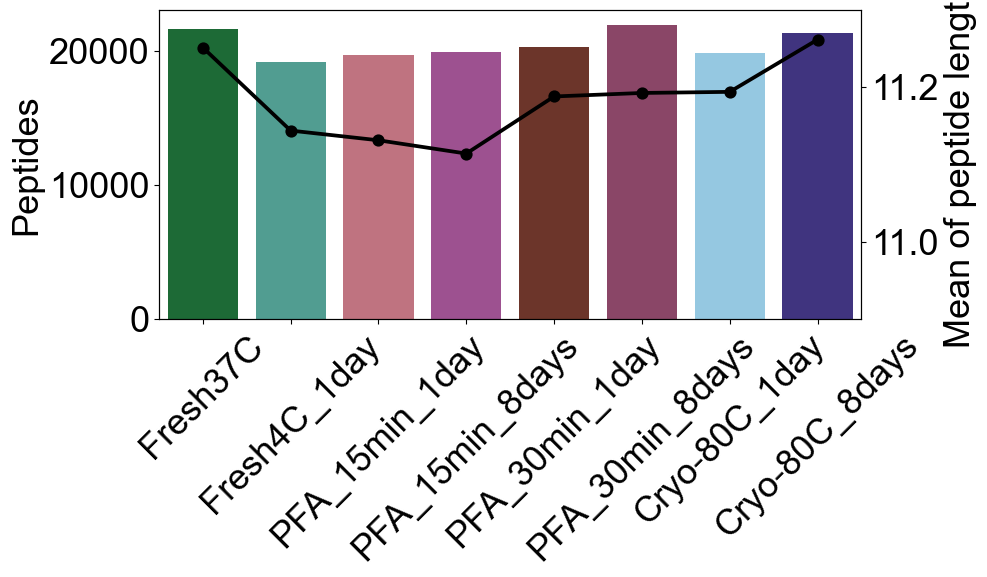

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(
    data=df_detected_counts,
    x="Condition",
    y="Detected_Peptides",
    palette=condition_colors,
    order=condition_colors.keys(),
    ax=ax1
)

ax1.set_ylabel("Peptides", color="black")
ax1.set_xlabel("")
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.pointplot(
    data=df_detected_counts,
    x="Condition",
    y="Mean_Peptide_Length",
    color="black",
    order=condition_colors.keys(),
    ax=ax2
)

ax2.set_ylabel("Mean of peptide length", color="black")
ax2.set_ylim(10.9, 11.3)

plt.title("", fontsize=14, weight='bold')
plt.tight_layout()
plt.grid(False)
plt.savefig("figures/HeLa/HeLa_Peptides_length.svg")


In [ ]:
peptide_counts = df.groupby("Genes")["Stripped.Sequence"].nunique().reset_index()
peptide_counts.rename(columns={"Stripped.Sequence": "PeptideCount"}, inplace=True)

In [ ]:
mean_peptides = peptide_counts["PeptideCount"].mean()

In [ ]:
print(f"Average of peptides per proteins: {mean_peptides:.2f}")

Average of peptides per proteins: 5.73


In [ ]:
df_filtered = df_long[df_long["Intensity"] > 0]

peptides_per_gene = (
    df_filtered.groupby(["Condition", "Genes"])["Stripped.Sequence"]
    .nunique()
    .reset_index(name="PeptidesPerGene")
)

mean_peptides_per_condition = (
    peptides_per_gene.groupby("Condition")["PeptidesPerGene"]
    .mean()
    .reset_index(name="MeanPeptides")
)

/tmp/ipykernel_485/334500757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


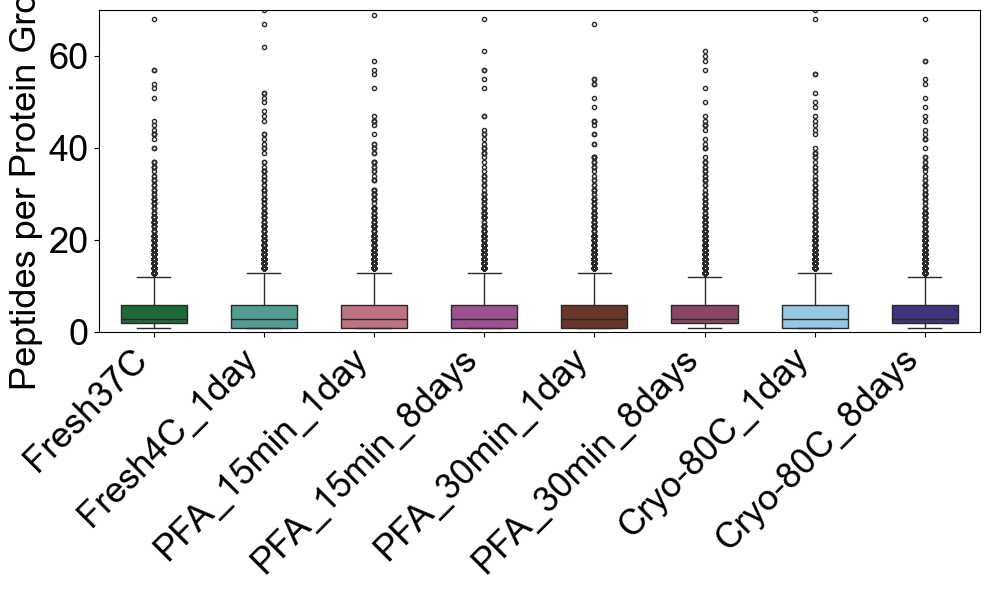

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=peptides_per_gene,
    x="Condition",
    y="PeptidesPerGene",
    palette=condition_colors,
    order=condition_colors.keys(),
    width=0.6,
    fliersize=3
)

plt.ylim(0, 70) # Set y-axis limits from 0 to 15
plt.title("", fontsize=14, weight="bold")
plt.xlabel("", fontsize=12)
plt.ylabel("Peptides per Protein Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("figures/HeLa/HeLa_Peptides_per_PG.svg")

In [ ]:
file_path = "PG_HeLa_Paper_Storage_DIA-NN_2p3_report_report.pg_matrix.tsv"

In [ ]:
df = pd.read_csv(file_path, sep="\t", index_col=0, encoding='latin-1')
df = df.fillna(0)

original_col_count = df.shape[1]

df = df.loc[:, (df != 0).sum() >= 0]

filtered_col_count = df.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} coluns were removed.")

0 coluns were removed.


In [ ]:
# exclude_df = pd.read_excel("Blanks_Common.xlsx")

# ids_to_exclude = exclude_df.iloc[:, 0].tolist()

# df = df[~df.iloc[:, 0].isin(ids_to_exclude)]

/tmp/ipykernel_485/2729304212.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_485/2729304212.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


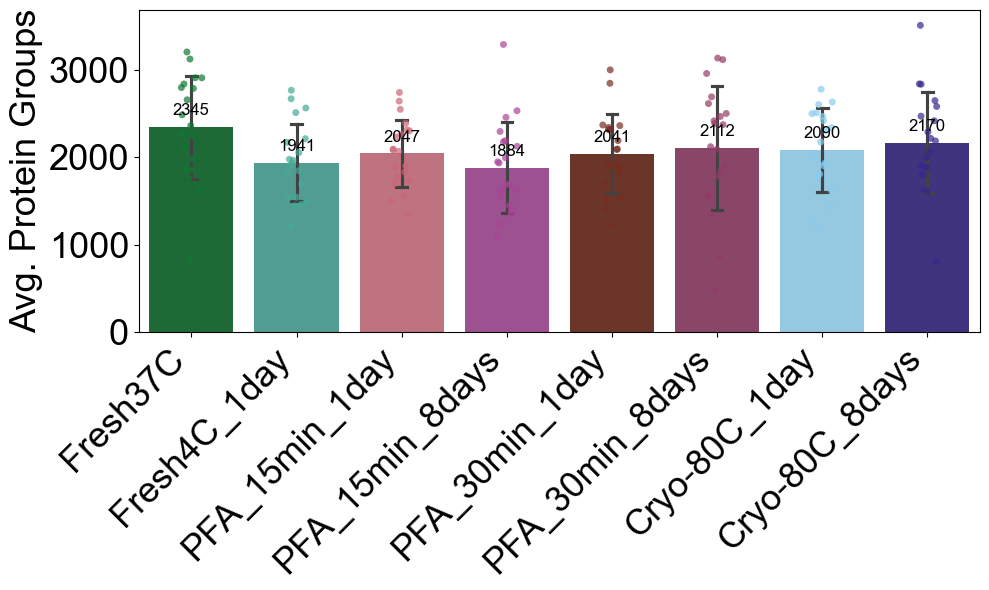

In [ ]:
protein_counts = (df > 0).sum(axis=0)

df_counts = pd.DataFrame({
    "Sample": protein_counts.index,
    "ProteinCount": protein_counts.values,
    "Condition": [extract_condition(s) for s in protein_counts.index]
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_counts,
    x="Condition", y="ProteinCount",
    order=condition_colors.keys(),  # garante ordem fixa
    palette=condition_colors,
    errorbar="sd",
    capsize=0.1
)

sns.stripplot(
    data=df_counts,
    x="Condition", y="ProteinCount",
    order=condition_colors.keys(),
    palette=condition_colors,
    color="gray", size=5, alpha=0.7,
    jitter=True
)

group_means = df_counts.groupby("Condition")["ProteinCount"].mean()
for i, cond in enumerate(condition_colors.keys()):
    mean_val = group_means[cond]
    plt.text(
        i, mean_val + 100, f"{int(mean_val)}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

plt.ylabel("Avg. Protein Groups")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

ax = plt.gca()
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

plt.savefig("figures/HeLa/HeLa_barplot_protein_groups_conditions.svg", dpi=300)
plt.show()


In [ ]:
file_path = "PG_HeLa_Paper_Storage_DIA-NN_2p3_report_report.pg_matrix.tsv"
df = pd.read_csv(file_path, sep='\t')
#df = df.fillna(0)

#df = df.drop(columns=["PG.Genes", "PG.FastaFiles", "PG.ProteinDescriptions"], errors='ignore')

condition_colors = {
    "Fresh37C": "#107732",
    "Fresh4C_1day": "#44aa99",
    "PFA_15min_1day": "#cc6677",
    "PFA_15min_8days": "#aa4499",
    "PFA_30min_1day": "#772d1f",
    "PFA_30min_8days": "#953b67",
    "Cryo-80C_1day": "#88ccee",
    "Cryo-80C_8days": "#38288b"
 }

condition_keywords = list(condition_colors.keys())

condition_keywords = ["Fresh37C", "Fresh4C_1day", "PFA_15min_1day", "PFA_15min_8days", "PFA_30min_1day", "PFA_30min_8days", "Cryo-80C_1day", "Cryo-80C_8days"]

condition_columns = {cond: [col for col in df.columns if cond in col] for cond in condition_keywords}

summary_data = {}
for cond, cols in condition_columns.items():
    mean_values = df[cols].mean(axis=1, skipna=True)
    std_values = df[cols].std(axis=1, skipna=True)
    cv_values = (std_values / mean_values) * 100  # CV% formula
    cv_values.replace([np.inf, -np.inf], np.nan, inplace=True)  # Handle division by zero

    summary_data[f"{cond}_mean"] = mean_values
    summary_data[f"{cond}_std"] = std_values
    summary_data[f"{cond}_cv"] = cv_values

summary_df = pd.DataFrame(summary_data)
summary_df.insert(0, "Genes", df["Genes"])

summary_df.to_csv("Final_Mean_Std_CV_Table_MS1.csv", sep='\t', index=False)

summary_df

,Genes,Fresh37C_mean,Fresh37C_std,Fresh37C_cv,Fresh4C_1day_mean,Fresh4C_1day_std,Fresh4C_1day_cv,PFA_15min_1day_mean,PFA_15min_1day_std,PFA_15min_1day_cv,...,PFA_30min_1day_cv,PFA_30min_8days_mean,PFA_30min_8days_std,PFA_30min_8days_cv,Cryo-80C_1day_mean,Cryo-80C_1day_std,Cryo-80C_1day_cv,Cryo-80C_8days_mean,Cryo-80C_8days_std,Cryo-80C_8days_cv
0,TRAJ52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IGHV3OR16-9,12437.900000,NaN,NaN,8187.210000,6919.167133,84.511905,2500.990000,NaN,NaN,...,NaN,2944.810000,NaN,NaN,NaN,NaN,NaN,7502.123333,3277.826434,43.691983
2,UBA6,1497.884500,546.996603,36.517943,1482.346000,649.804811,43.836244,742.246200,337.163253,45.424719,...,40.778051,1199.591500,599.675401,49.989967,1354.274429,587.419092,43.375189,1458.980235,545.075956,37.360064
3,ESYT2,2115.063842,1090.718748,51.569070,2118.600000,625.505977,29.524496,2560.551500,795.022713,31.048886,...,36.954921,2222.190588,647.867942,29.154472,1641.521538,358.664779,21.849532,2034.149941,848.778921,41.726468
4,SHTN1,1021.138933,457.583191,44.811061,803.224750,417.183112,51.938528,580.406700,174.141931,30.003432,...,30.285312,439.214625,77.279298,17.594883,736.489444,254.865748,34.605485,815.061533,403.008617,49.445177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,SCIN,NaN,NaN,NaN,NaN,NaN,NaN,1096.370000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4539,PCLO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,135.902935,923304.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4540,WASF2,1229.292333,258.944396,21.064509,1256.934375,367.018960,29.199532,1109.881643,245.183178,22.090930,...,16.984155,1108.246857,369.820618,33.369877,1286.047889,447.837635,34.822781,1140.127750,281.215392,24.665253
4541,IVNS1ABP,628.475200,121.908709,19.397537,NaN,NaN,NaN,584.080000,NaN,NaN,...,NaN,532.141000,26.481149,4.976341,787.859000,NaN,NaN,659.673250,167.986424,25.465096


/tmp/ipykernel_485/640788704.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="CV (%)", data=cv_data, palette=[condition_colors[cond.replace("_cv", "")] for cond in cv_columns])


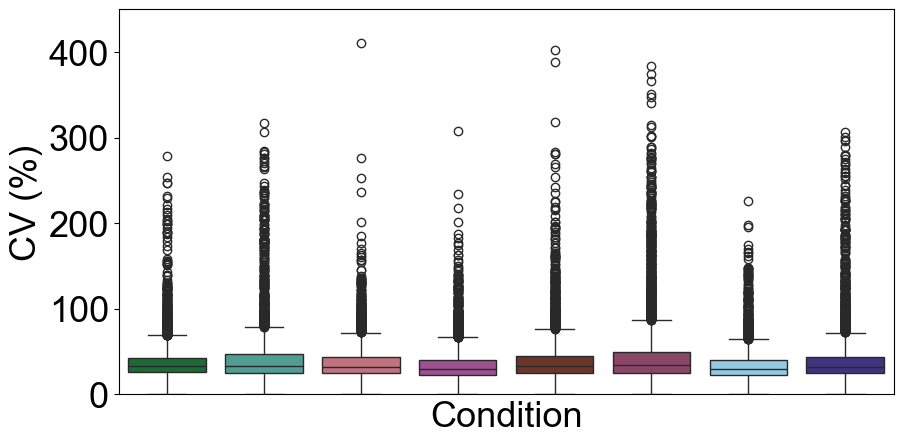

,Genes,Fresh37C_mean,Fresh37C_std,Fresh37C_cv,Fresh4C_1day_mean,Fresh4C_1day_std,Fresh4C_1day_cv,PFA_15min_1day_mean,PFA_15min_1day_std,PFA_15min_1day_cv,...,PFA_30min_1day_cv,PFA_30min_8days_mean,PFA_30min_8days_std,PFA_30min_8days_cv,Cryo-80C_1day_mean,Cryo-80C_1day_std,Cryo-80C_1day_cv,Cryo-80C_8days_mean,Cryo-80C_8days_std,Cryo-80C_8days_cv
0,TRAJ52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IGHV3OR16-9,12437.900000,NaN,NaN,8187.210000,6919.167133,84.511905,2500.990000,NaN,NaN,...,NaN,2944.810000,NaN,NaN,NaN,NaN,NaN,7502.123333,3277.826434,43.691983
2,UBA6,1497.884500,546.996603,36.517943,1482.346000,649.804811,43.836244,742.246200,337.163253,45.424719,...,40.778051,1199.591500,599.675401,49.989967,1354.274429,587.419092,43.375189,1458.980235,545.075956,37.360064
3,ESYT2,2115.063842,1090.718748,51.569070,2118.600000,625.505977,29.524496,2560.551500,795.022713,31.048886,...,36.954921,2222.190588,647.867942,29.154472,1641.521538,358.664779,21.849532,2034.149941,848.778921,41.726468
4,SHTN1,1021.138933,457.583191,44.811061,803.224750,417.183112,51.938528,580.406700,174.141931,30.003432,...,30.285312,439.214625,77.279298,17.594883,736.489444,254.865748,34.605485,815.061533,403.008617,49.445177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,SCIN,NaN,NaN,NaN,NaN,NaN,NaN,1096.370000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4539,PCLO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,135.902935,923304.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4540,WASF2,1229.292333,258.944396,21.064509,1256.934375,367.018960,29.199532,1109.881643,245.183178,22.090930,...,16.984155,1108.246857,369.820618,33.369877,1286.047889,447.837635,34.822781,1140.127750,281.215392,24.665253
4541,IVNS1ABP,628.475200,121.908709,19.397537,NaN,NaN,NaN,584.080000,NaN,NaN,...,NaN,532.141000,26.481149,4.976341,787.859000,NaN,NaN,659.673250,167.986424,25.465096


In [ ]:
cv_columns = [f"{cond}_cv" for cond in condition_keywords]
cv_data = summary_df[cv_columns].melt(var_name="Condition", value_name="CV (%)")

plt.figure(figsize=(10, 5))
sns.boxplot(x="Condition", y="CV (%)", data=cv_data, palette=[condition_colors[cond.replace("_cv", "")] for cond in cv_columns])
plt.xticks(rotation=45, ha='right')
plt.xticks([])
plt.ylabel("CV (%)")
plt.title("")
plt.ylim(0, 450)

plt.savefig("figures/HeLa/CV_Distribution.svg")
plt.show()

summary_df

In [ ]:
file_path = "PEP_HeLa_Paper_Storage_DIA-NN_2p3_report.pr_matrix.tsv"

In [ ]:
df = pd.read_csv(file_path, sep="\t", index_col=0, encoding='latin-1')
df = df.fillna(0)

original_col_count = df.shape[1]

df = df.loc[:, (df != 0).sum() >= 0]

filtered_col_count = df.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} coluns were removed.")

0 coluns were removed.


/tmp/ipykernel_485/1411429223.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_485/1411429223.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


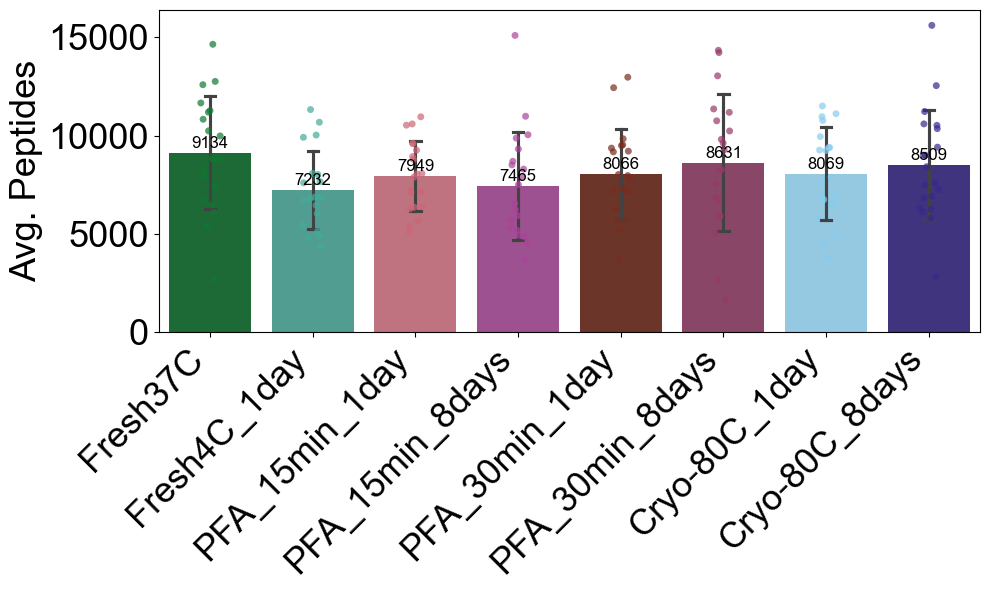

In [ ]:
peptide_counts = (df > 0).sum(axis=0)

df_counts = pd.DataFrame({
    "Sample": peptide_counts.index,
    "Stripped.Sequence": peptide_counts.values,
    "Condition": [extract_condition(s) for s in peptide_counts.index]
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_counts,
    x="Condition", y="Stripped.Sequence",
    order=condition_colors.keys(),  # garante ordem fixa
    palette=condition_colors,
    errorbar="sd",
    capsize=0.1
)

sns.stripplot(
    data=df_counts,
    x="Condition", y="Stripped.Sequence",
    order=condition_colors.keys(),
    palette=condition_colors,
    color="gray", size=5, alpha=0.7,
    jitter=True
)

group_means = df_counts.groupby("Condition")["Stripped.Sequence"].mean()
for i, cond in enumerate(condition_colors.keys()):
    mean_val = group_means[cond]
    plt.text(
        i, mean_val + 100, f"{int(mean_val)}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

plt.ylabel("Avg. Peptides")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

ax = plt.gca()
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

plt.savefig("figures/HeLa/HeLa_barplot_peptides_conditions.svg", dpi=300)
plt.show()

In [ ]:
file_name = "HeLa_Paper_storage_DIANN_transposed.tsv"

data = pd.read_csv(file_name, sep="\t")

In [ ]:
condition_names = {
    "Fresh37C": "37 ºC (Control)",
    "Fresh4C_1day": "4 ºC (1 day)",
    "PFA_15min_1day": "PFA 2% 15 min 4 ºC (1 day)",
    "PFA_15min_8days": "PFA 2% 15 min 4 ºC (8 days)",
    "PFA_30min_1day": "PFA 2% 30 min 4 ºC (1 day)",
    "PFA_30min_8days": "PFA 2% 30 min 4 ºC (8 days)",
    "Cryo-80C_1day": "-80 ºC (1 day)",
    "Cryo-80C_8days": "-80 ºC (8 days)"
}

data["Condition"] = data["Condition"].replace(condition_names)
control_condition = "37 ºC (Control)"

In [ ]:
control_data = data[data["Condition"] == control_condition].drop(columns="Condition")
control_data = control_data.replace(0, np.nan)

In [ ]:
volcano_results = []

pseudo_count = 1

for condition in data["Condition"].unique():
    if condition == control_condition:
        continue

    condition_data = data[data["Condition"] == condition].drop(columns="Condition")
    condition_data = condition_data.replace(0, np.nan)

    mean_control = control_data.mean(skipna=True) + pseudo_count
    mean_condition = condition_data.mean(skipna=True) + pseudo_count

    log2fc = np.log2(mean_condition / mean_control)

    p_values = []
    for protein in condition_data.columns:
        valid_control = control_data[protein].dropna()
        valid_condition = condition_data[protein].dropna()

        if len(valid_control) >= 2 and len(valid_condition) >= 2:
            p = ttest_ind(valid_condition, valid_control, equal_var=False).pvalue
        else:
            p = np.nan
        p_values.append(p)

    temp_df = pd.DataFrame({
        "Protein": condition_data.columns,
        "log2FoldChange": log2fc.values,
        "p_value": p_values
    }).dropna(subset=["p_value"])

    temp_df["AdjustedPValue"] = multipletests(
        temp_df["p_value"], method="fdr_bh"
    )[1]

    temp_df["-log10(AdjustedPValue)"] = -np.log10(temp_df["AdjustedPValue"])
    temp_df["Significant"] = temp_df["AdjustedPValue"] < 0.05

    temp_df["Regulation"] = np.where(
        temp_df["log2FoldChange"] > 1, "Up",
        np.where(temp_df["log2FoldChange"] < -1, "Down", "No Change")
    )

    temp_df["Condition"] = condition
    volcano_results.append(temp_df)


In [ ]:
volcano_df = pd.concat(volcano_results, ignore_index=True)

volcano_df.to_csv("volcano_data_hela.tsv", sep="\t", index=False)
print("Volcano data successfully generated!")

Volcano data successfully generated!


In [ ]:
conditions_order = [
    "PFA 2% 15 min 4 ºC (1 day)",
    "PFA 2% 15 min 4 ºC (8 days)",
    "PFA 2% 30 min 4 ºC (1 day)",
    "PFA 2% 30 min 4 ºC (8 days)",
    "-80 ºC (1 day)",
    "-80 ºC (8 days)",
    "4 ºC (1 day)"
]

In [ ]:
def volcano_plot(df, condition, control_condition, ax,
                 max_labels=15):

    df = df.copy()

    sig_mask = (df["AdjustedPValue"] < 0.05) & (df["log2FoldChange"].abs() >= 1)

    df["Regulation"] = np.where(
        sig_mask & (df["log2FoldChange"] > 0), "Up",
        np.where(sig_mask & (df["log2FoldChange"] < 0), "Down", "No Change")
    )

    palette = {
        "Up": "#EE6363",
        "Down": "#1874CD",
        "No Change": "gainsboro"
    }

    sns.scatterplot(
        data=df,
        x="log2FoldChange",
        y="-log10(AdjustedPValue)",
        hue="Regulation",
        palette=palette,
        ax=ax,
        s=35,
        alpha=0.7,
        linewidth=0,
        legend=False
    )

    ax.axhline(-np.log10(0.05), ls="--", c="black", lw=0.8)
    ax.axvline(-1, ls="--", c="black", lw=0.8)
    ax.axvline(1, ls="--", c="black", lw=0.8)

    n_up = ((df["Regulation"] == "Up")).sum()
    n_down = ((df["Regulation"] == "Down")).sum()

    ax.text(
        0.98, 0.95,
        f"Up: {n_up}\nDown: {n_down}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.6)
    )

    label_df = (
        df[sig_mask]
        .sort_values("AdjustedPValue")
        .groupby("Regulation")
        .head(max_labels // 2)
    )

    texts = []
    for _, row in label_df.iterrows():
        texts.append(
            ax.text(
                row["log2FoldChange"],
                row["-log10(AdjustedPValue)"],
                row["Protein"],
                fontsize=14
            )
        )

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.3, 1.5),
        expand_text=(1.2, 1.4),
        arrowprops=dict(arrowstyle="-", lw=0.5, color="black"),
        force_text=0.5,
        force_points=0.3
    )

    ax.set_title(f"{condition} vs {control_condition}", fontsize=18, weight="bold")
    ax.set_xlabel("log2(Fold Change)", fontsize=16)
    ax.set_ylabel("-log10(Adjusted P-value)", fontsize=16)
    ax.tick_params(axis="both", labelsize=12)

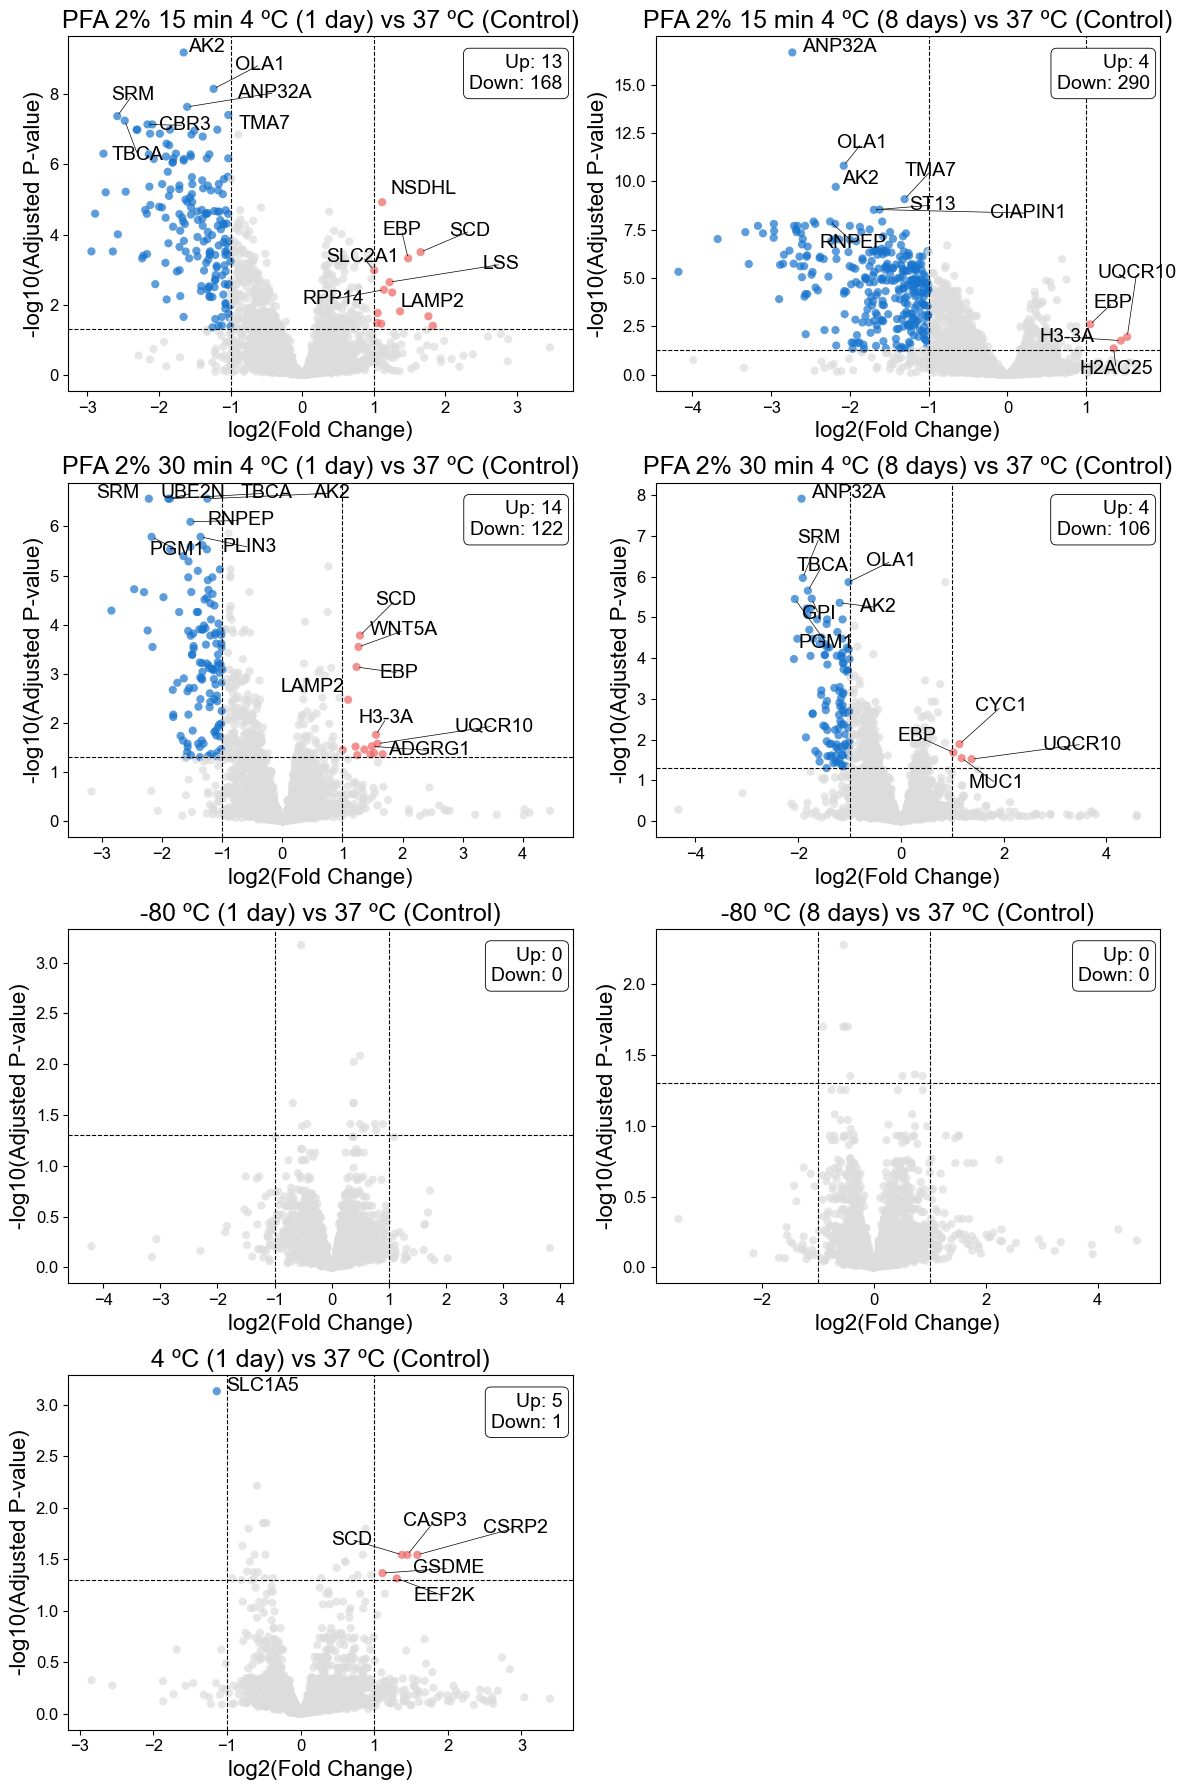

In [ ]:
valid_conditions = [c for c in conditions_order if c in volcano_df["Condition"].unique()]

ncols = 2
nrows = int(np.ceil(len(valid_conditions) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 18))
axes = axes.flatten()

for ax, condition in zip(axes, valid_conditions):
    cond_df = volcano_df[volcano_df["Condition"] == condition]
    volcano_plot(cond_df, condition, control_condition, ax)

for ax in axes[len(valid_conditions):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("volcano_panel_hela.png", dpi=300)
plt.savefig("volcano_panel_hela.svg")
plt.show()

In [ ]:
conditions_order = [
    "PFA 2% 15 min 4 ºC (1 day)",
    "PFA 2% 15 min 4 ºC (8 days)",
    "PFA 2% 30 min 4 ºC (1 day)",
    "PFA 2% 30 min 4 ºC (8 days)"
]

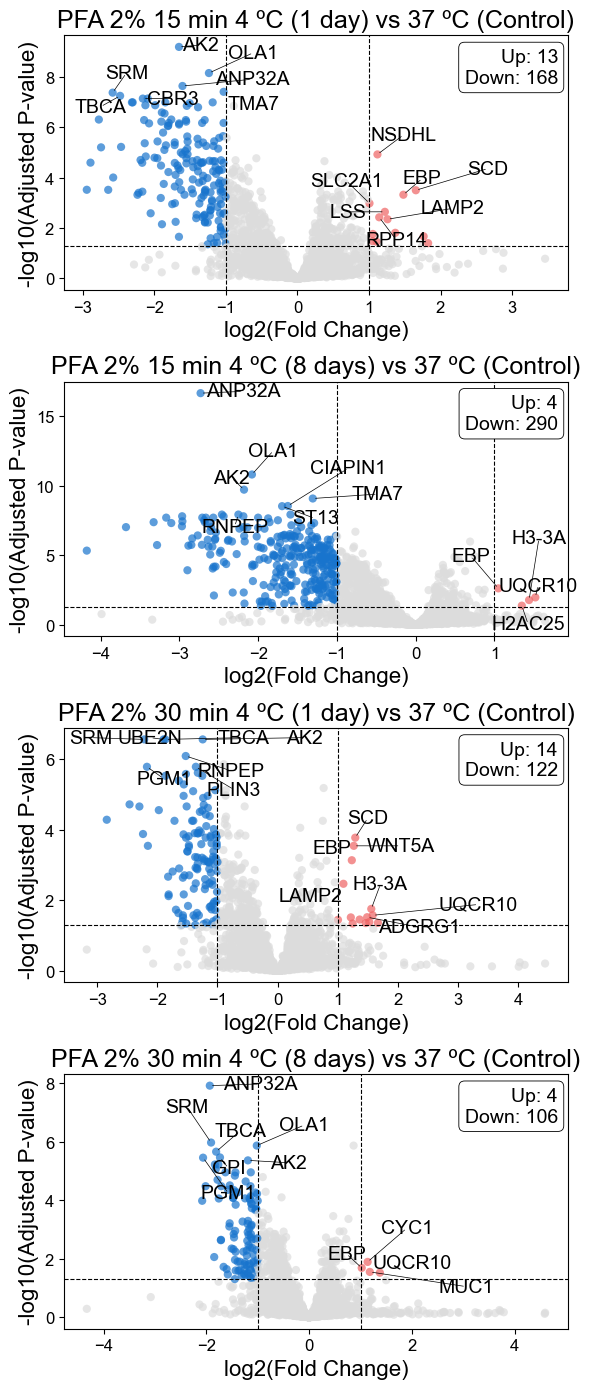

In [ ]:
valid_conditions = [
    c for c in conditions_order
    if c in volcano_df["Condition"].unique()
]

ncols = 1
nrows = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(6, 14))
axes = axes.flatten()

for ax, condition in zip(axes, valid_conditions):
    cond_df = volcano_df[volcano_df["Condition"] == condition]
    volcano_plot(cond_df, condition, control_condition, ax)

for ax in axes[len(valid_conditions):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("figures/HeLa/volcano_panel_hela_pfa.png", dpi=600)
plt.savefig("figures/HeLa/volcano_panel_hela_pfa.svg")
plt.show()

GO

/tmp/ipykernel_485/325903777.py:78: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: collapse_go_terms(x, similarity_threshold=0.5))
/tmp/ipykernel_485/325903777.py:138: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


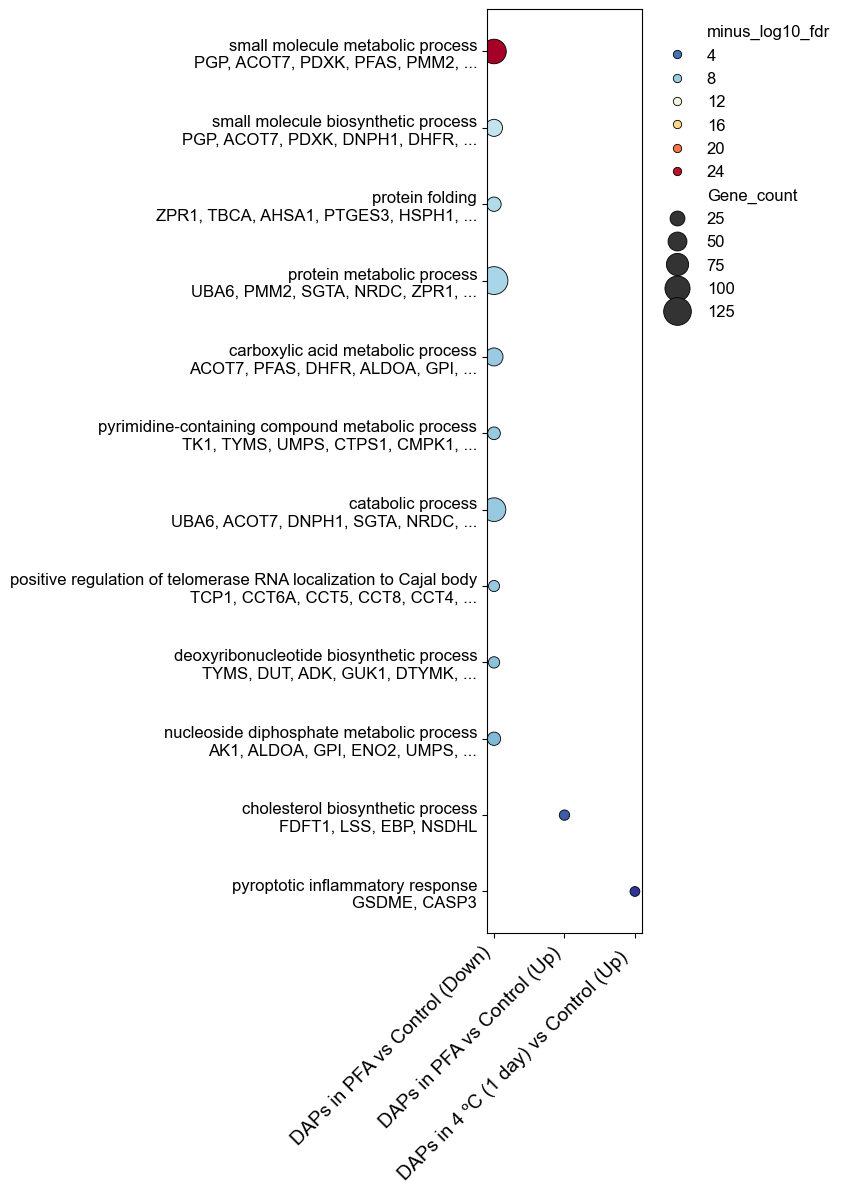

In [ ]:
def format_genes(gene_list):

    if isinstance(gene_list, str):
        genes = gene_list.split(",")
    else:
        genes = list(gene_list)

    genes = [g.strip() for g in genes]
    genes = list(dict.fromkeys(genes))

    if len(genes) > 5:
        return ", ".join(genes[:5]) + ", ..."
    else:
        return ", ".join(genes)

def collapse_go_terms(df, similarity_threshold=0.5):

    df = df.sort_values("p_value").copy()

    removed = set()

    gene_sets = {
        idx: set(str(row["intersections"]).split(","))
        for idx, row in df.iterrows()
    }

    for i, j in combinations(df.index, 2):

        if j in removed:
            continue

        g1 = gene_sets[i]
        g2 = gene_sets[j]

        jaccard = len(g1 & g2) / len(g1 | g2)

        if jaccard >= similarity_threshold:
            removed.add(j)

    return df.drop(index=list(removed))

df = pd.read_excel("hela_volcano.xlsx")

gp = GProfiler(return_dataframe=True)

go_results = []

for condition in df.columns:

    genes = df[condition].dropna().astype(str).unique().tolist()

    if len(genes) == 0:
        continue

    res = gp.profile(
        organism="hsapiens",
        query=genes,
        sources=["GO:BP"],
        no_evidences=False
    )

    if res is not None and not res.empty:
        res["Condition"] = condition
        go_results.append(res)

if len(go_results) == 0:
    raise ValueError("Nenhum enrichment encontrado")

go_df = pd.concat(go_results, ignore_index=True)

go_df = go_df[go_df["significant"] == True].copy()

go_df["minus_log10_fdr"] = -np.log10(go_df["p_value"])

go_df = (
    go_df
    .groupby("Condition", group_keys=False)
    .apply(lambda x: collapse_go_terms(x, similarity_threshold=0.5))
)

top_terms = (
    go_df
    .sort_values("p_value")
    .groupby("Condition")
    .head(10)
)


plot_df = top_terms.rename(columns={
    "name": "GO_term",
    "intersection_size": "Gene_count"
})

term_order = (
    plot_df
    .groupby("GO_term")["minus_log10_fdr"]
    .mean()
    .sort_values(ascending=True)
    .index
)


plot_df["Gene_label"] = plot_df["intersections"].apply(format_genes)

plot_df["GO_label"] = (
    plot_df["GO_term"] + "\n" + plot_df["Gene_label"]
)

plt.figure(figsize=(2, 12))

ax = sns.scatterplot(
    data=plot_df,
    x="Condition",
    y="GO_label",
    size="Gene_count",
    hue="minus_log10_fdr",
    palette="RdYlBu_r",
    sizes=(50, 400),
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=12)

plt.xlabel("")
plt.ylabel("")

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=12,
    title_fontsize=12
)

plt.tight_layout()

plt.savefig(
    "figures/HeLa/GO_enrichment_dotplot_hela_volcano.svg",
    dpi=300
)

plt.show()

In [ ]:
!zip -r figures_HeLa.zip figures/HeLa/

  adding: figures/HeLa/ (stored 0%)
  adding: figures/HeLa/Boxplot_HeLa_elongation_stats.svg (deflated 74%)
  adding: figures/HeLa/Correlation_CellDiameter_HeLa.svg (deflated 78%)
  adding: figures/HeLa/GO_enrichment_dotplot_hela_volcano.svg (deflated 83%)
  adding: figures/HeLa/Boxplot_HeLa_elongation.svg (deflated 74%)
  adding: figures/HeLa/HeLa_Peptides_per_PG.svg (deflated 95%)
  adding: figures/HeLa/HeLa_barplot_protein_groups_conditions.svg (deflated 83%)
  adding: figures/HeLa/volcano_panel_hela_pfa.png (deflated 9%)
  adding: figures/HeLa/Heatmap_HeLa_topmarkers.svg (deflated 93%)
  adding: figures/HeLa/UMAP_HeLa.svg (deflated 74%)
  adding: figures/HeLa/Boxplot_HeLa_morphometrics_circularity_stats.svg (deflated 79%)
  adding: figures/HeLa/PCA_HeLa.svg (deflated 85%)
  adding: figures/HeLa/Boxplot_HeLa_Circularity_stats.svg (deflated 75%)
  adding: figures/HeLa/HeLa_Peptides_length.svg (deflated 79%)
  adding: figures/HeLa/Boxplot_HeLa_morphometrics_diameter_stats.svg (deflate

# PBMC single-cell (benchmarking)

In [ ]:
file_path = "pbmc_benchmarking_report_pg_matrix_DIA-NN2p3.tsv"

In [ ]:
data = pd.read_csv(file_path, sep="\t", encoding='latin-1')
original_col_count = data.shape[1]
data = data.fillna(0)
data = data.loc[:, (data != 0).sum() >= 150]

filtered_col_count = data.shape[1]
removed_cols = original_col_count - filtered_col_count

In [ ]:
exclude_data = pd.read_excel("Blanks_Common_PBMC_benchmarking.xlsx")

ids_to_exclude = exclude_data.iloc[:, 0].tolist()

data = data[~data.iloc[:, 0].isin(ids_to_exclude)]

In [ ]:
condition_colors = {
    "Fresh": "#51A940",
    "Cryopreserved": "#3779E7"
}

In [ ]:
transposed_data = data.set_index("Genes").transpose()

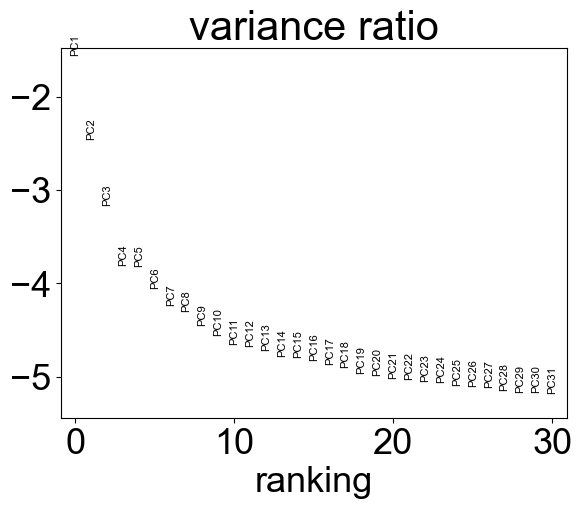

PC1: 21.07%
PC2: 29.62%
PC3: 33.85%
PC4: 36.07%
PC5: 38.25%
PC6: 39.97%
PC7: 41.41%
PC8: 42.76%
PC9: 43.93%
PC10: 44.98%
PC11: 45.93%
PC12: 46.86%
PC13: 47.75%
PC14: 48.58%
PC15: 49.41%
PC16: 50.20%
PC17: 50.97%
PC18: 51.71%
PC19: 52.40%
PC20: 53.08%
PC21: 53.74%
PC22: 54.39%
PC23: 55.03%
PC24: 55.66%
PC25: 56.27%
PC26: 56.88%
PC27: 57.48%
PC28: 58.06%
PC29: 58.63%
PC30: 59.19%
PC31: 59.75%
PC32: 60.31%
PC33: 60.85%
PC34: 61.39%
PC35: 61.92%
PC36: 62.44%
PC37: 62.96%
PC38: 63.48%
PC39: 63.99%
PC40: 64.49%
PC41: 65.00%
PC42: 65.50%
PC43: 65.99%
PC44: 66.48%
PC45: 66.97%
PC46: 67.45%
PC47: 67.92%
PC48: 68.39%
PC49: 68.86%
PC50: 69.33%
PC51: 69.79%
PC52: 70.25%
PC53: 70.69%
PC54: 71.14%
PC55: 71.59%
PC56: 72.02%
PC57: 72.46%
PC58: 72.89%
PC59: 73.32%
PC60: 73.75%
PC61: 74.17%
PC62: 74.59%
PC63: 75.00%
PC64: 75.41%
PC65: 75.82%
PC66: 76.23%
PC67: 76.63%
PC68: 77.03%
PC69: 77.42%
PC70: 77.81%
PC71: 78.19%
PC72: 78.58%
PC73: 78.96%
PC74: 79.33%
PC75: 79.71%
PC76: 80.08%
PC77: 80.45%
PC78: 80

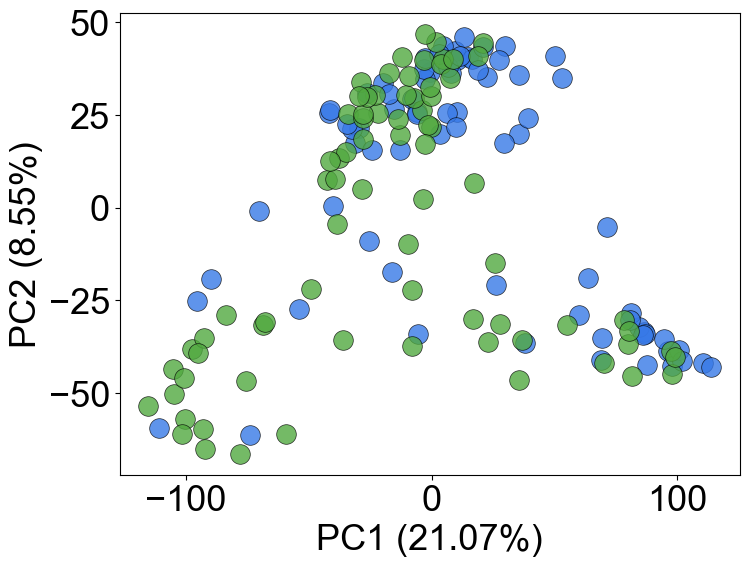

In [ ]:
valid_samples = [sample for sample in transposed_data.index if "_" in sample]

condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return "Unknown"

sample_conditions = [extract_condition(row) for row in transposed_data.index]

adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs["condition"] = sample_conditions

sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=100)

explained_variance_ratio = adata.uns["pca"]["variance_ratio"]
pc1_var = explained_variance_ratio[0] * 100
pc2_var = explained_variance_ratio[1] * 100

sc.pl.pca_variance_ratio(adata, log=True, n_pcs=30)

cumulative_variance = np.cumsum(adata.uns["pca"]["variance_ratio"])
for i, v in enumerate(cumulative_variance):
    print(f"PC{i+1}: {v*100:.2f}%")


plt.figure(figsize=(8, 6))

unique_conditions = [c for c in np.unique(sample_conditions) if c is not None]

pc1 = adata.obsm["X_pca"][:, 0]
pc2 = adata.obsm["X_pca"][:, 1]

for condition in unique_conditions:
    mask = np.array(sample_conditions) == condition
    plt.scatter(pc1[mask], pc2[mask], label=condition, color=condition_colors.get(condition, "#000000"), edgecolor='black', linewidth=0.5, alpha=0.8, s=200)


plt.xlabel(f"PC1 ({pc1_var:.2f}%)")
plt.ylabel(f"PC2 ({pc2_var:.2f}%)")
plt.title("")

#plt.legend(title="", bbox_to_anchor=(1, 1), loc="upper left")
plt.grid(False)
plt.savefig("figures/PBMC_benchmarking/PCA_PBMC_benchmarking.svg")

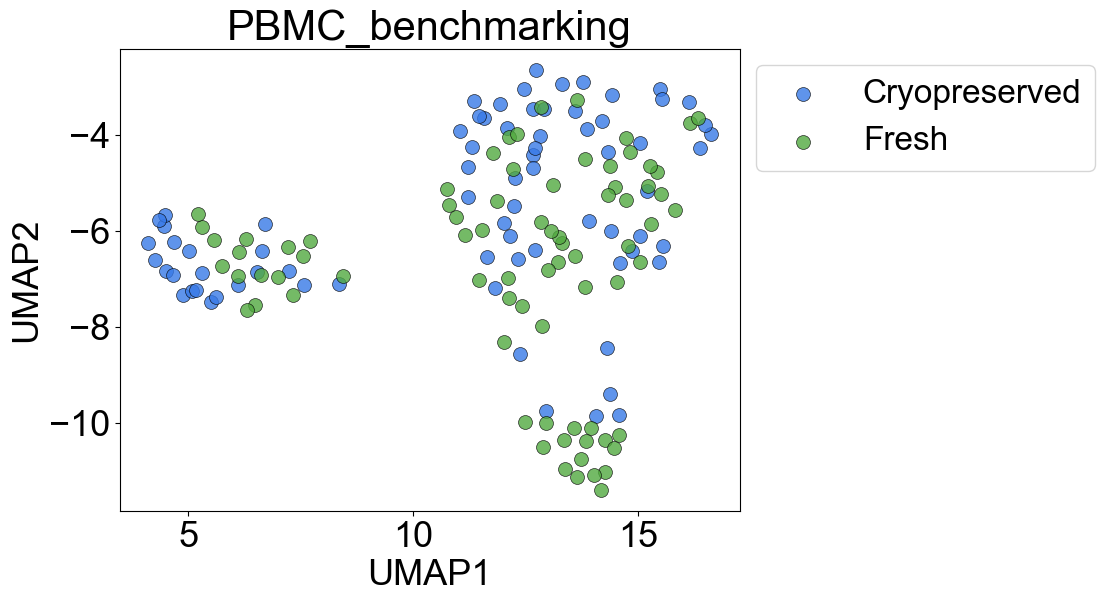

In [ ]:
filtered_data = transposed_data.loc[valid_samples]

obs_data = pd.DataFrame({"condition": sample_conditions}, index=valid_samples)

adata = sc.AnnData(filtered_data.values, obs=obs_data)

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=20)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

umap_results = adata.obsm["X_umap"]
umap1 = umap_results[:, 0]
umap2 = -umap_results[:, 1]

plt.figure(figsize=(8, 6))

for condition in np.unique(sample_conditions):
    mask = obs_data["condition"] == condition
    plt.scatter(umap1[mask], umap2[mask], label=condition,
                color=condition_colors.get(condition, "#000000"), alpha=0.8, s=100, edgecolor='black', linewidth=0.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("PBMC_benchmarking")
plt.legend(title="", bbox_to_anchor=(1, 1), loc="upper left")
plt.grid(False)

In [ ]:
diameter_df = pd.read_excel("morphometrics_pbmc_benchmarking.xlsx")
diameter_df = diameter_df[diameter_df["Protein Groups"] >= 150]

diameter_df = diameter_df.set_index("Sample")

adata.obs["Diameter"] = diameter_df["Diameter"].values

In [ ]:
adata.obs["protein_count"] = (transposed_data.loc[valid_samples] > 0).sum(axis=1).values

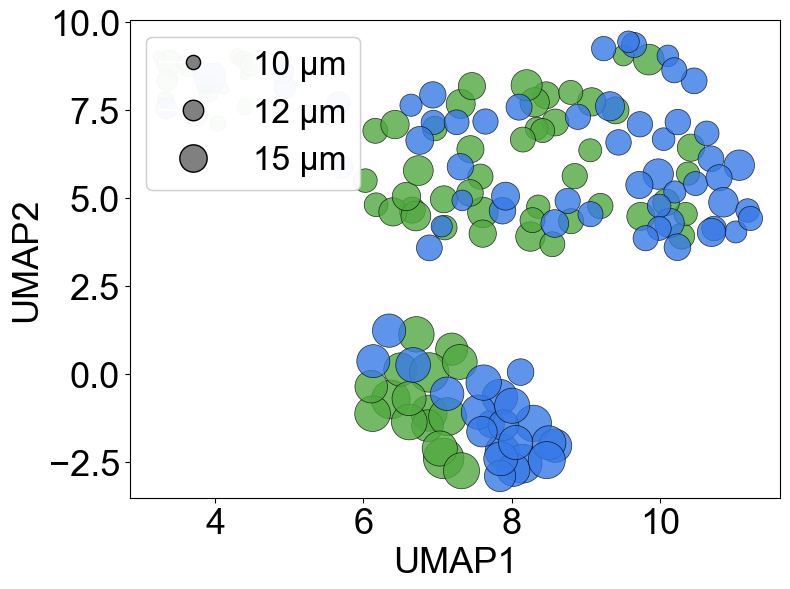

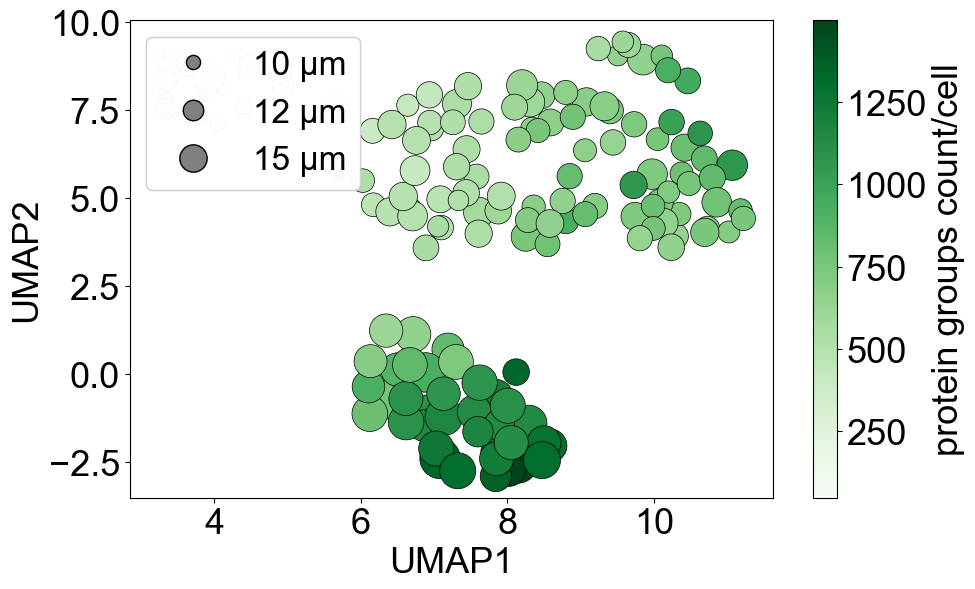

In [ ]:
diameters = pd.to_numeric(adata.obs["Diameter"], errors='coerce').fillna(0)
sizes = ((diameters - diameters.min()) / (diameters.max() - diameters.min())) * 800 + 50
sc.tl.umap(adata, random_state=42)

x = adata.obsm['X_umap'][:, 0]
y = adata.obsm['X_umap'][:, 1]

colors_condition = adata.obs["condition"].map(condition_colors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x, y,
    s=sizes,
    c=colors_condition,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.5,
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)

ref_sizes = [10, 12, 15]
scaled_ref_sizes = ((np.array(ref_sizes) - diameters.min()) / (diameters.max() - diameters.min())) * 400 + 50
ref_labels = [f"{s} µm" for s in ref_sizes]
ref_markers = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='gray', markersize=np.sqrt(scaled), label=label,
                      markeredgecolor='k') for scaled, label in zip(scaled_ref_sizes, ref_labels)]
legend1 = plt.legend(handles=ref_markers, title="", loc='upper left')
plt.gca().add_artist(legend1)

plt.tight_layout()
plt.savefig("figures/PBMC_benchmarking/UMAP_PBMC_benchmarking.svg")
plt.show()

colors_protein_count = adata.obs["protein_count"]

plt.figure(figsize=(9.9, 6))
scatter = plt.scatter(
    x, y,
    s=sizes,
    c=colors_protein_count,
    cmap="Greens",
    alpha=1,
    edgecolors='black',
    linewidths=0.5,
)

cbar = plt.colorbar(scatter)
cbar.set_label("protein groups count/cell")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)

legend2 = plt.legend(handles=ref_markers, title="", loc='upper left')
plt.gca().add_artist(legend2)

plt.tight_layout()
plt.savefig("figures/PBMC_benchmarking/UMAP_PBMC_benchmarking_Protein_Count.svg")
plt.show()

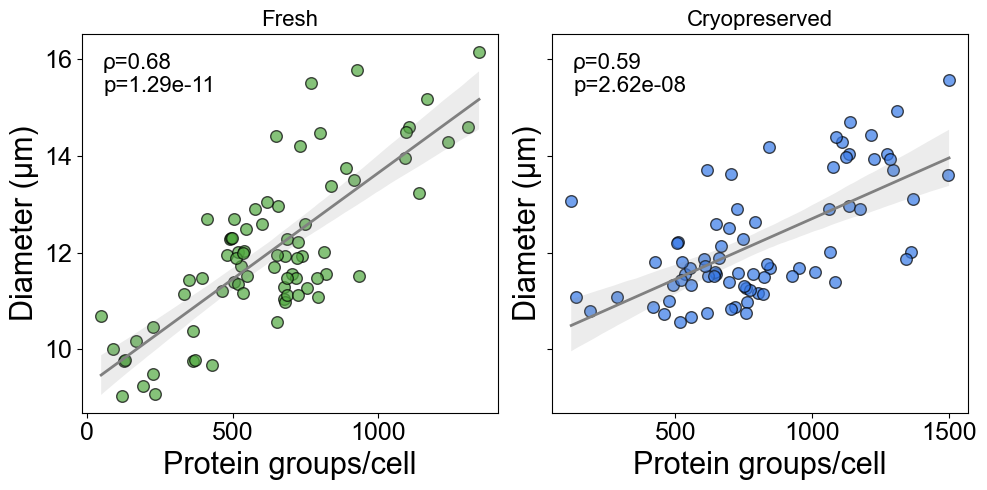

In [ ]:
diameters = pd.to_numeric(adata.obs["Diameter"], errors='coerce').fillna(0)
protein_counts = pd.to_numeric(adata.obs["protein_count"], errors='coerce').fillna(0)
conditions = adata.obs["condition"]

df = pd.DataFrame({
    "Diameter": diameters,
    "ProteinGroups": protein_counts,
    "Condition": conditions
})

unique_conditions = df["Condition"].unique()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes = axes.flatten()

for ax, cond in zip(axes, unique_conditions):
    sub = df[df["Condition"] == cond]

    r, p = spearmanr(sub["ProteinGroups"], sub["Diameter"])

    color = condition_colors[cond] if cond in condition_colors else "gray"

    sns.regplot(
        data=sub,
        x="ProteinGroups",
        y="Diameter",
        scatter_kws={
            "s": 70,
            "alpha": 0.7,
            "edgecolor": "black",
            "color": color
        },
        line_kws={
            "color": "gray",
            "linewidth": 2
        },
        ax=ax
    )

    ax.set_title(cond, fontsize=16, fontweight="bold")
    ax.set_xlabel("Protein groups/cell", fontsize=22)
    ax.set_ylabel("Diameter (µm)", fontsize=22)
    ax.tick_params(axis="both", labelsize=18)

    ax.text(
    0.05, 0.95,
    f"ρ={r:.2f}\np={p:.2e}",
    transform=ax.transAxes,
    fontsize=16,
    verticalalignment="top",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("figures/PBMC_benchmarking/Correlation_Diameter_PG_PBMC_benchmarking.svg")
plt.show()


/tmp/ipykernel_508/2684471789.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden", resolution=1)
/tmp/ipykernel_508/2684471789.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leiden_condition_map = adata.obs.groupby('leiden')['condition'].agg(lambda x: x.mode()[0]).to_dict()


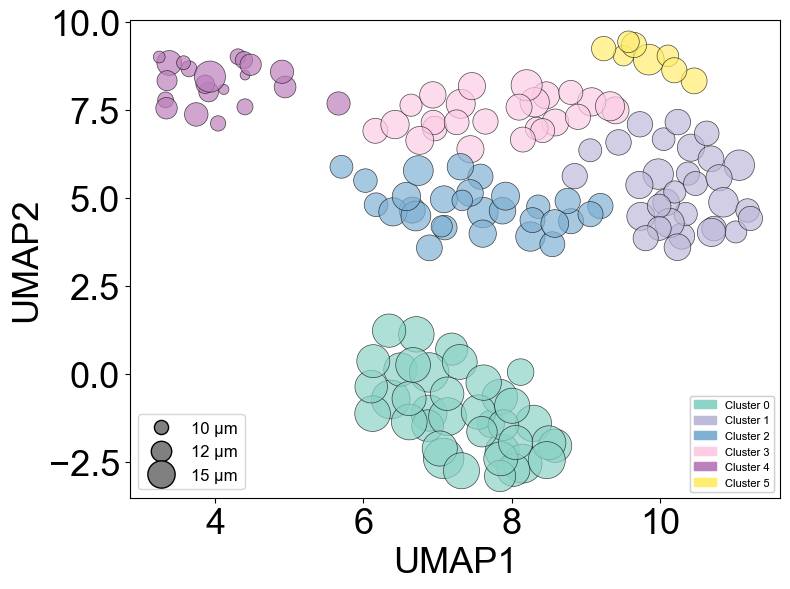

In [ ]:
sc.tl.leiden(adata, key_added="leiden", resolution=1)

leiden_condition_map = adata.obs.groupby('leiden')['condition'].agg(lambda x: x.mode()[0]).to_dict()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x, y,
    s=sizes,
    c=adata.obs["leiden"].astype('category').cat.codes,
    cmap="Set3",
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5,
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)

ref_sizes = [10, 12, 15]
scaled_ref_sizes = ((np.array(ref_sizes) - diameters.min()) / (diameters.max() - diameters.min())) * 400 + 50
ref_labels = [f"{s} µm" for s in ref_sizes]
ref_markers = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='gray', markersize=np.sqrt(scaled), label=label,
                      markeredgecolor='k') for scaled, label in zip(scaled_ref_sizes, ref_labels)]
legend1 = plt.legend(handles=ref_markers, title="", loc='best',  fontsize=12)
plt.gca().add_artist(legend1)

clusters = adata.obs["leiden"].astype('category').cat.categories
colors = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

patches = [mpatches.Patch(color=colors[i], label=f"Cluster {cl}")
           for i, cl in enumerate(clusters)]

legend2 = plt.legend(
    handles=patches,
    title="",
    loc='lower right',
    fontsize=8
)

plt.gca().add_artist(legend2)


plt.tight_layout()
plt.savefig("figures/PBMC_benchmarking/UMAP_PBMC_benchmarking_Leiden_r1.svg")
plt.show()

In [ ]:
umap1 = adata.obsm["X_umap"][:, 0]
umap2 = adata.obsm["X_umap"][:, 1]

df_umap = pd.DataFrame({
    "Sample": adata.obs_names,
    "UMAP1": umap1,
    "UMAP2": umap2,
    "Leiden": adata.obs["leiden"].astype(str),
    "Condition": adata.obs["condition"].astype(str)
})

df_umap.head()

,Sample,UMAP1,UMAP2,Leiden,Condition
E:\usuarios\heloisa_prado_mas\PBMC_storage_rawfiles\20250625_PBMC_Storage_New\PBMC_Fresh_Patient_CTL_Plate1\PBMC_Fresh_Batch1\20250626_PBMC_Fresh_Patient1_CTL_A4.raw,E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...,3.379108,8.839490,4,Fresh
E:\usuarios\heloisa_prado_mas\PBMC_storage_rawfiles\20250625_PBMC_Storage_New\PBMC_Fresh_Patient_CTL_Plate1\PBMC_Fresh_Batch1\20250626_PBMC_Fresh_Patient1_CTL_A6.raw,E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...,6.885525,-1.101530,0,Fresh
E:\usuarios\heloisa_prado_mas\PBMC_storage_rawfiles\20250625_PBMC_Storage_New\PBMC_Fresh_Patient_CTL_Plate1\PBMC_Fresh_Batch1\20250626_PBMC_Fresh_Patient1_CTL_A7.raw,E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...,3.911114,8.014284,4,Fresh
E:\usuarios\heloisa_prado_mas\PBMC_storage_rawfiles\20250625_PBMC_Storage_New\PBMC_Fresh_Patient_CTL_Plate1\PBMC_Fresh_Batch1\20250626_PBMC_Fresh_Patient1_CTL_A8.raw,E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...,7.579894,5.611380,2,Fresh
E:\usuarios\heloisa_prado_mas\PBMC_storage_rawfiles\20250625_PBMC_Storage_New\PBMC_Fresh_Patient_CTL_Plate1\PBMC_Fresh_Batch1\20250626_PBMC_Fresh_Patient1_CTL_A10.raw,E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...,6.963548,6.977621,3,Fresh


In [ ]:
df_umap.to_csv("table_umap/PBMC_benchmarking_UMAP_coordinates_with_leiden.tsv", sep="\t", index=False)

/tmp/ipykernel_508/2082773290.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_diameter_stats = adata.obs.groupby('leiden')['Diameter'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_508/2082773290.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Average Diameter and Standard Deviation per Leiden Cluster:
  Leiden Cluster  Average Diameter  Diameter Std Dev
0              0         14.078684          0.905458
1              1         11.648065          0.571025
2              2         11.740000          0.586369
3              3         11.815600          0.535608
4              4         10.322381          0.946784
5              5         11.387500          0.762323


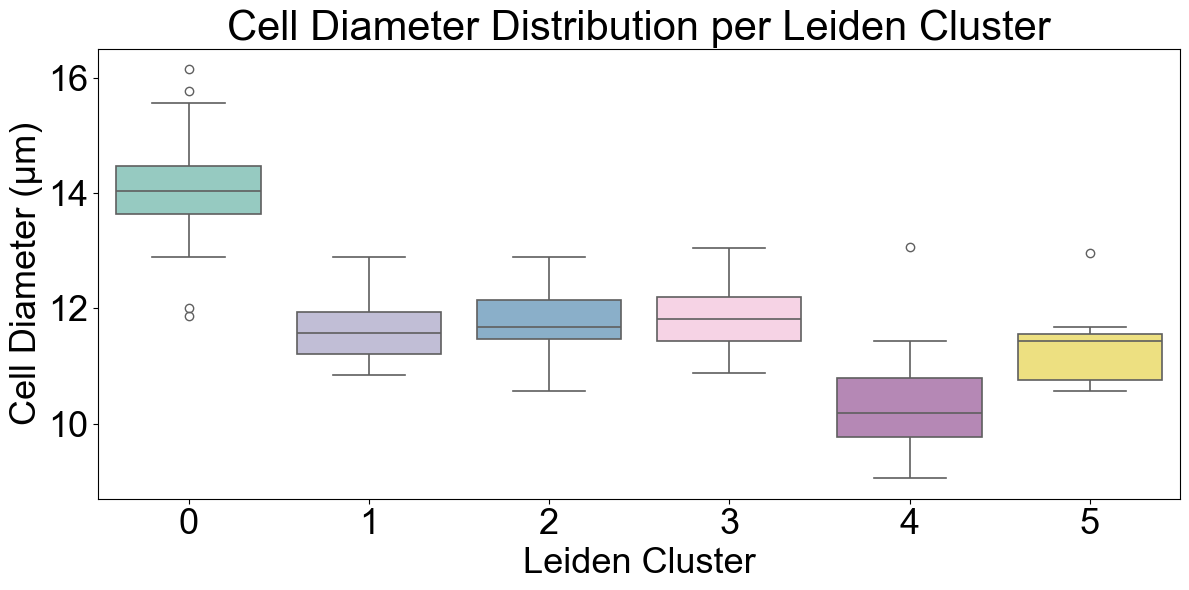

In [ ]:
cluster_diameter_stats = adata.obs.groupby('leiden')['Diameter'].agg(['mean', 'std']).reset_index()
cluster_diameter_stats.columns = ['Leiden Cluster', 'Average Diameter', 'Diameter Std Dev']

print("Average Diameter and Standard Deviation per Leiden Cluster:")
print(cluster_diameter_stats)

clusters = adata.obs["leiden"].astype('category').cat.categories
colors = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

cluster_colors = dict(zip(clusters, colors))

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='leiden',
    y='Diameter',
    data=adata.obs,
    palette=cluster_colors,
    linewidth=1.2
)

plt.xlabel("Leiden Cluster")
plt.ylabel("Cell Diameter (µm)")
plt.title("Cell Diameter Distribution per Leiden Cluster")
plt.grid(False)
plt.tight_layout()
plt.savefig("figures/PBMC_benchmarking/Boxplot_PBMC_benchmarking.svg")
plt.show()

In [ ]:
groups = [
    adata.obs.loc[adata.obs["leiden"] == cluster, "Diameter"].dropna()
    for cluster in adata.obs["leiden"].unique()
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H = {stat:.3f}")
print(f"p-value = {p_value:.3e}")

Kruskal-Wallis H = 101.312
p-value = 2.795e-20


In [ ]:
df_stats = adata.obs[["leiden", "Diameter"]].dropna()

dunn_results = sp.posthoc_dunn(
    df_stats,
    val_col="Diameter",
    group_col="leiden",
    p_adjust="fdr_bh"
)

print(dunn_results)

              0             1             2             3             4  \
0  1.000000e+00  1.367642e-09  4.654979e-08  7.740467e-07  1.056138e-19   
1  1.367642e-09  1.000000e+00  6.675936e-01  5.127463e-01  7.000952e-04   
2  4.654979e-08  6.675936e-01  1.000000e+00  7.732907e-01  1.655192e-04   
3  7.740467e-07  5.127463e-01  7.732907e-01  1.000000e+00  1.069509e-04   
4  1.056138e-19  7.000952e-04  1.655192e-04  1.069509e-04  1.000000e+00   
5  5.989227e-06  5.127463e-01  3.791962e-01  3.115535e-01  1.537950e-01   

          5  
0  0.000006  
1  0.512746  
2  0.379196  
3  0.311554  
4  0.153795  
5  1.000000  


In [ ]:
df = adata.obs[["leiden", "Diameter"]].dropna().copy()
df["leiden"] = df["leiden"].astype(str)

clusters = df["leiden"].unique()

results = []

for c1, c2 in combinations(clusters, 2):
    g1 = df.loc[df["leiden"] == c1, "Diameter"]
    g2 = df.loc[df["leiden"] == c2, "Diameter"]

    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")

    results.append({
        "cluster_1": c1,
        "cluster_2": c2,
        "p_value": p
    })

df_stats = pd.DataFrame(results)

df_stats["p_adj"] = multipletests(
    df_stats["p_value"],
    method="fdr_bh"
)[1]

sig_pairs_df = df_stats[df_stats["p_adj"] < 0.05]

print(sig_pairs_df)


  cluster_1 cluster_2       p_value         p_adj
0         4         0  4.207350e-10  1.577756e-09
1         4         2  7.264169e-07  1.574810e-06
2         4         3  7.349115e-07  1.574810e-06
3         4         1  7.320811e-07  1.574810e-06
4         4         5  4.993668e-03  8.322780e-03
5         0         2  2.065747e-11  1.549311e-10
6         0         3  1.955596e-10  9.777978e-10
7         0         1  5.853777e-12  8.780666e-11
8         0         5  1.785421e-05  3.347665e-05


In [ ]:
pairs = list(
    zip(
        sig_pairs_df["cluster_1"],
        sig_pairs_df["cluster_2"]
    )
)

print("Pares significativos:", pairs)

Pares significativos: [('4', '0'), ('4', '2'), ('4', '3'), ('4', '1'), ('4', '5'), ('0', '2'), ('0', '3'), ('0', '1'), ('0', '5')]


In [ ]:
valid_samples = [sample for sample in transposed_data.index if "_" in sample]
condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return None

sample_conditions = [extract_condition(row) for row in transposed_data.index]

unmatched_conditions = [row for row, condition in zip(transposed_data.index, sample_conditions) if condition is None]
if unmatched_conditions:
    print("Amostras sem correspondência de condição:", unmatched_conditions)

colors = [condition_colors.get(condition, "#000000") for condition in sample_conditions]

adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs["condition"] = sample_conditions
adata.var_names = transposed_data.columns

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=20)

sc.pp.neighbors(adata)

sc.tl.umap(adata)
sc.tl.umap(adata, random_state=42)

sc.tl.leiden(adata, resolution=1)

/tmp/ipykernel_508/2752064023.py:31: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1)


In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden",
    pts=True,
    pts_rest=True
)

In [ ]:
marker_genes = []
all_markers = []
groups = adata.obs["leiden"].unique().tolist()

X = adata.X

for group in groups:
    print(f"Processando cluster {group}...")

    df = sc.get.rank_genes_groups_df(adata, group=group, key="dea_leiden")
    df = df.dropna(subset=["logfoldchanges", "pvals_adj"])

    genes = df["names"].values

    idx_in = adata.obs["leiden"] == group
    X_in = X[idx_in, :]

    idx_out = adata.obs["leiden"] != group
    X_out = X[idx_out, :]

    pct_in = []
    pct_out = []

    for g in genes:
        gene_idx = adata.var_names.get_loc(g)

        if hasattr(X_in, "A"):
            pct_in_val = (X_in[:, gene_idx].A > 0).mean()
            pct_out_val = (X_out[:, gene_idx].A > 0).mean()
        else:
            pct_in_val = (X_in[:, gene_idx] > 0).mean()
            pct_out_val = (X_out[:, gene_idx] > 0).mean()

        pct_in.append(pct_in_val)
        pct_out.append(pct_out_val)

    df = df.copy()
    df["pct_in"] = pct_in
    df["pct_out"] = pct_out

    df_filtered = df[
        (df["pvals_adj"] < 0.05) &
        (df["logfoldchanges"] > 1) &
        (df["pct_in"] > 0.6) &
        (df["pct_out"] < 0.2)
    ]

    marker_genes.extend(df_filtered["names"].tolist())

    df_filtered["cluster"] = group
    all_markers.append(df_filtered)

final_df = pd.concat(all_markers, ignore_index=True)

marker_genes = list(dict.fromkeys(marker_genes))

print(marker_genes)

final_df.to_csv("table_markers/PBMC_benchmarking_leiden_marker_genes_with_pct.tsv", sep="\t", index=False)

Processando cluster 4...
Processando cluster 0...


/tmp/ipykernel_508/4277979208.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["cluster"] = group


Processando cluster 2...
Processando cluster 3...


/tmp/ipykernel_508/4277979208.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["cluster"] = group
/tmp/ipykernel_508/4277979208.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["cluster"] = group


Processando cluster 1...
Processando cluster 5...
['LRRC59', 'ATP6V1E1', 'CYBB', 'CTSS', 'CTSZ', 'KCTD12', 'MNDA', 'TRIM25', 'SYK', 'BLVRA', 'AIF1', 'NCF2', 'FCN1', 'HYOU1', 'RAB3D', 'CD63', 'APOBR', 'PICALM', 'BLVRB', 'PRAM1', 'RAB32', 'CES1', 'ATP6V1G1', 'PLIN3', 'SIRPA', 'PRKCD', 'LYN', 'CPVL', 'MARCKS', 'RALB', 'SULT1A1', 'RP2', 'ATP2A2', 'CAPG', 'CD14', 'ADA2', 'STMN2', 'PADI4', 'F13A1', 'RAB5C', 'PLEKHO2', 'FBP1', 'BASP1', 'NCF4', 'ALDH2', 'HK3', 'ATL3', 'STMN1', 'STXBP2', 'MGST1', 'ARHGEF2', 'DNM1L', 'CORO1C', 'LRRC25', 'RSU1', 'AGTRAP', 'CYBA', 'DPYD', 'FCER1G', 'FGR', 'GCA', 'ERO1A', 'EVI2B', 'SNX27', 'EHD4', 'BSG', 'NCF1', 'HVCN1', 'PARVG', 'PHGDH', 'ATP6V0D1', 'GNB4', 'ARAP1', 'WARS1', 'NME2', 'CORO1B', 'PDXK', 'MCEMP1', 'PECAM1', 'ITGAX', 'CHMP4B', 'ITGA2B', 'VPS29', 'PSMC1', 'EIF4G1', 'NIPSNAP3A', 'SNX1', 'CPT1A', 'CLTA', 'PACSIN2', 'TOM1', 'DYSF', 'USO1', 'LAP3', 'ANPEP', 'TARS1', 'ADGRE5', 'CHP1', 'COLGALT1', 'TBXAS1', 'BST1', 'HSD17B11', 'NARS1', 'LRP1', 'FKBP15', 'HEBP

/tmp/ipykernel_508/4277979208.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["cluster"] = group


Genes após filtragem: 218
Exclusive selected (top by logFC):
{'0': ['AIF1', 'PRAM1', 'SNX27', 'RBP7', 'ADGRE5'], '3': ['DGKA'], '1': ['PRF1', 'RASAL3', 'APOBEC3G', 'CD3D'], '5': ['MS4A1', 'CD37', 'SWAP70', 'PDLIM1', 'CD74']}
categories: 0, 1, 2, etc.
var_group_labels: 0, 3, 1, etc.


/tmp/ipykernel_508/2416599108.py:71: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


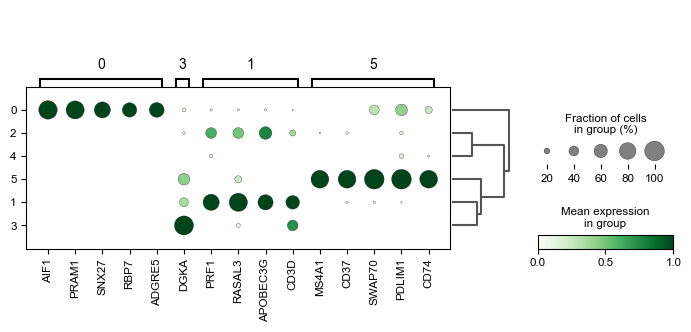

In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df = full_df[full_df["pvals_adj"] < 0.05]

X = adata.X
groups = adata.obs["leiden"].unique().tolist()

pct_in_list = []
pct_out_list = []

for idx, row in full_df.iterrows():
    gene = row["names"]
    group = row["group"]

    gene_idx = adata.var_names.get_loc(gene)

    idx_in = adata.obs["leiden"] == group
    idx_out = adata.obs["leiden"] != group

    X_in = X[idx_in, gene_idx]
    X_out = X[idx_out, gene_idx]

    if hasattr(X_in, "A"):
        pct_in = (X_in.A > 0).mean()
        pct_out = (X_out.A > 0).mean()
    else:
        pct_in = (X_in > 0).mean()
        pct_out = (X_out > 0).mean()

    pct_in_list.append(pct_in)
    pct_out_list.append(pct_out)

full_df["pct_in"] = pct_in_list
full_df["pct_out"] = pct_out_list


filtered_df = full_df[
    (full_df["logfoldchanges"] > 1) &
    (full_df["pct_in"] > 0.6) &
    (full_df["pct_out"] < 0.2)
]

print("Genes após filtragem:", filtered_df.shape[0])

exclusive_genes = {}

for group in groups:
    cluster_df = filtered_df[filtered_df["group"] == group]

    cluster_genes = set(cluster_df["names"])
    other_genes = set(filtered_df[filtered_df["group"] != group]["names"])
    exclusive = cluster_genes - other_genes

    df = cluster_df[cluster_df["names"].isin(exclusive)]
    df = df.sort_values("logfoldchanges", ascending=False).head(5)

    if not df.empty:
        exclusive_genes[group] = df["names"].tolist()

print("Exclusive selected (top by logFC):")
print(exclusive_genes)

adata.var_names_make_unique()

sc.pl.dotplot(
    adata,
    var_names=exclusive_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="Greens",
    dendrogram=True,
    show=True,
    save="PBMC_benchmarking_dotplot.svg"
)

!mv figures/dotplot_PBMC_benchmarking_dotplot.svg figures/PBMC_benchmarking/

/tmp/ipykernel_508/2995928091.py:10: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


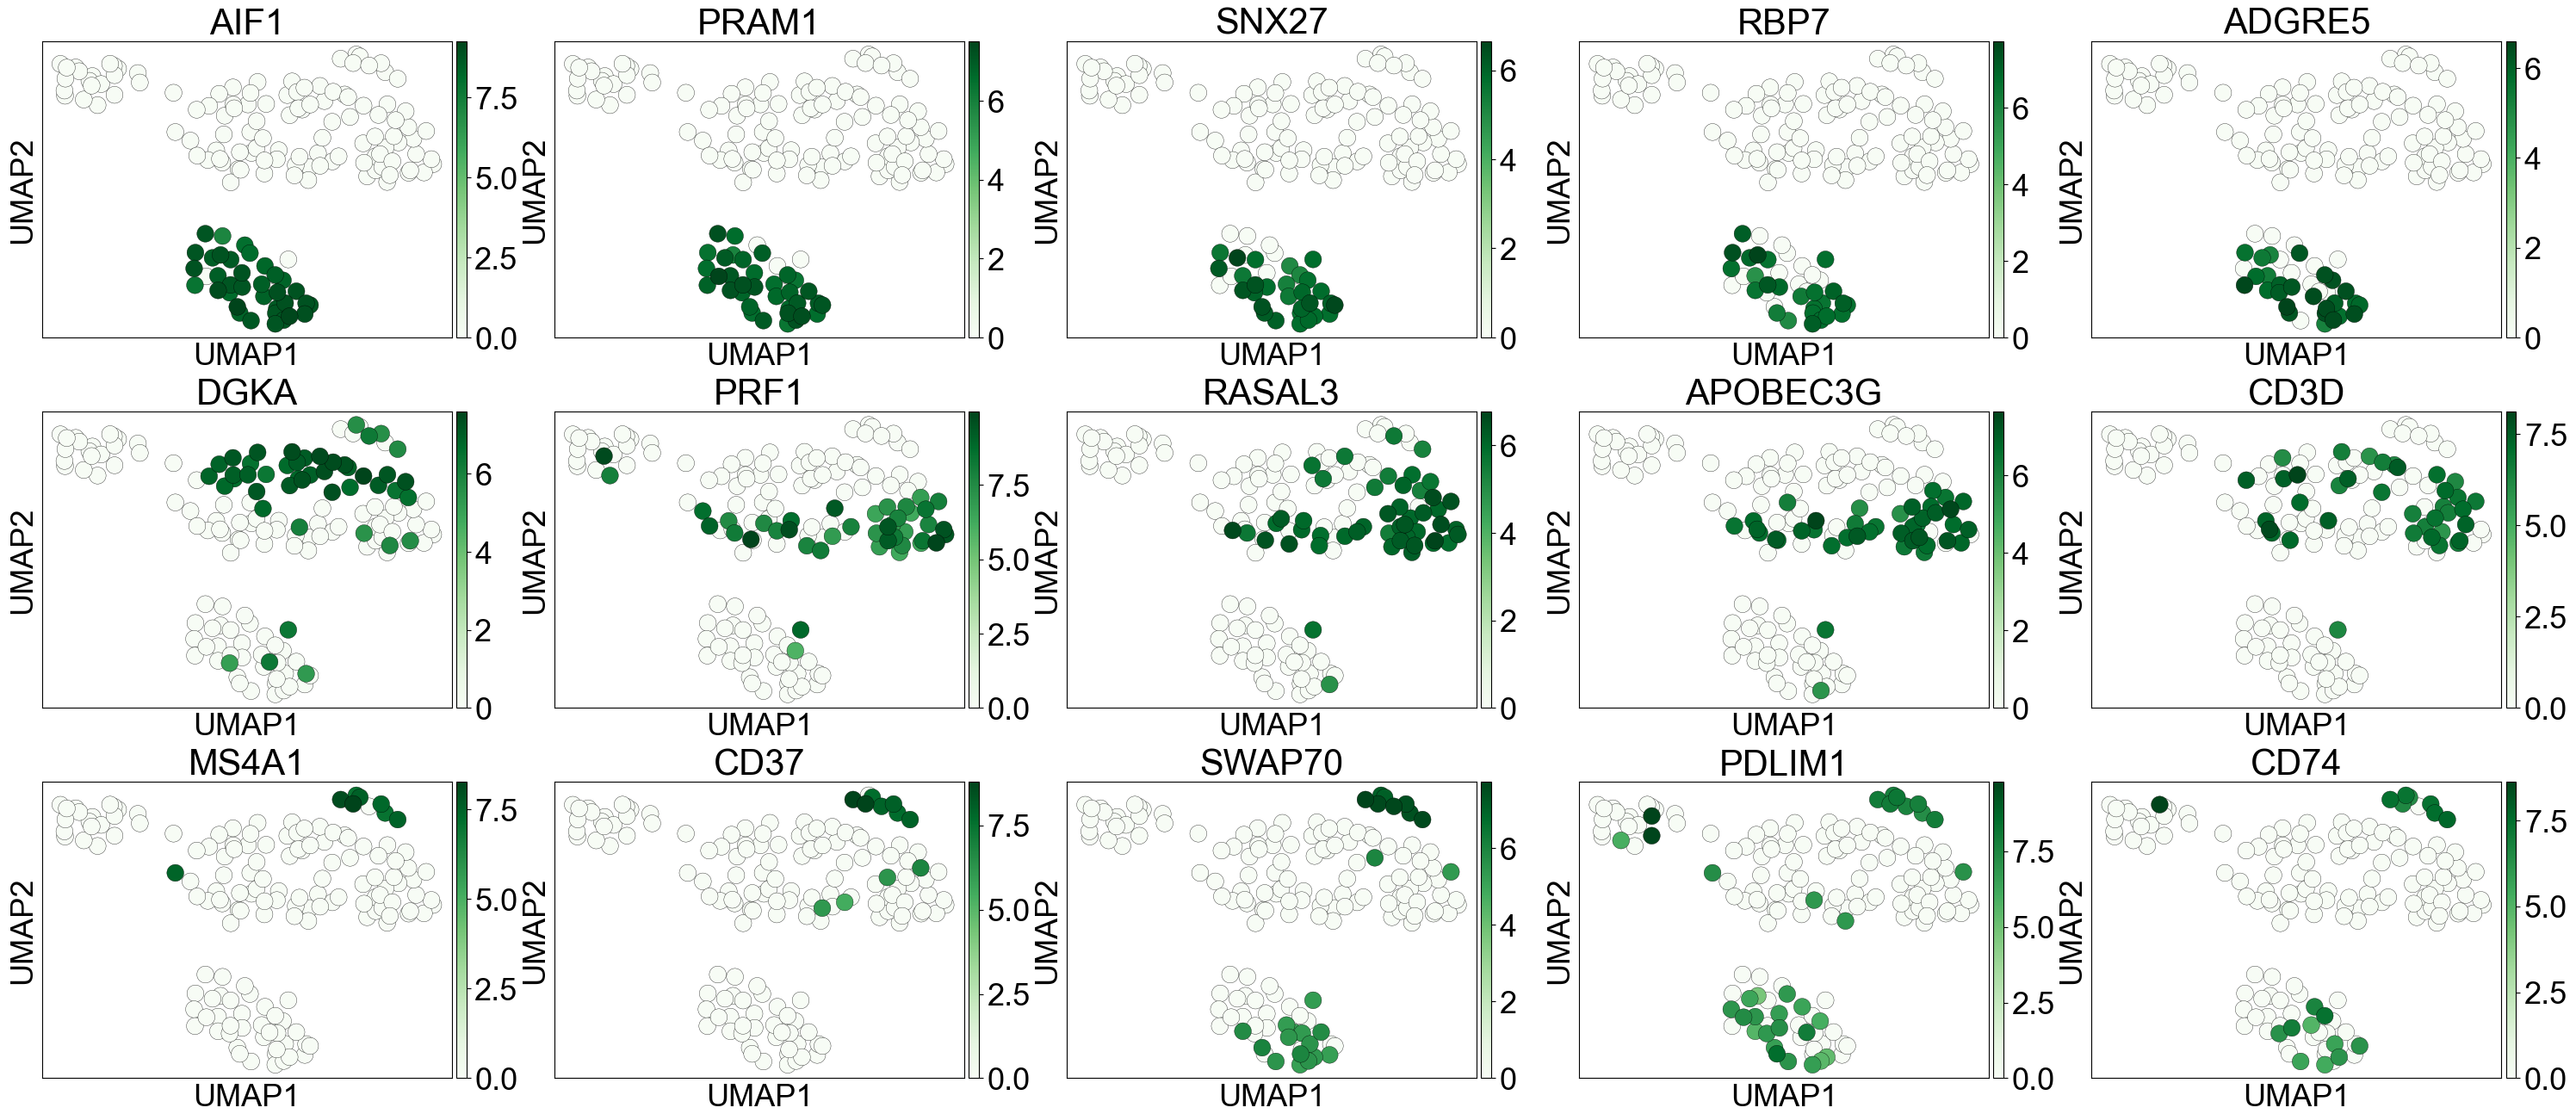

In [ ]:
adata.var_names_make_unique()

all_exclusive_genes = []
for genes_list in exclusive_genes.values():
    all_exclusive_genes.extend(genes_list)

present_genes = [gene for gene in all_exclusive_genes if gene in adata.var_names]

if present_genes:
    sc.pl.umap(
        adata,
        color=present_genes,
        cmap="Greens",
        size=800,
        linewidth=0.25,
        edgecolor='black',
        ncols=5,
        save="_PG_UMAP_highlight_leiden_selected_genes.svg"
    )

!mv figures/umap_PG_UMAP_highlight_leiden_selected_genes.svg figures/PBMC_benchmarking/

In [ ]:
valid_marker_genes = [gene for gene in all_exclusive_genes if gene in adata.var_names]
expr_matrix = adata[:, valid_marker_genes].to_df()
expr_matrix = expr_matrix.loc[expr_matrix.std(axis=1) != 0]
expr_matrix = expr_matrix.apply(lambda r: (r - r.mean()) / r.std(), axis=1)
expr_matrix = expr_matrix.T

leiden_labels = adata.obs["leiden"].astype(str)
n_clusters = len(leiden_labels.unique())
leiden_colors = cm.get_cmap('Set3', n_clusters).colors
leiden_color_dict = dict(zip(sorted(leiden_labels.unique()), leiden_colors))
leiden_col = leiden_labels.map(leiden_color_dict)

condition_labels = adata.obs["condition"].astype(str)

condition_colors = {
    "Fresh": "#51A940",
    "Cryopreserved": "#3779E7"
}

condition_col = condition_labels.map(condition_colors)

col_colors = pd.concat([leiden_col, condition_col], axis=1)
col_colors.columns = ["Leiden", "Condition"]

/tmp/ipykernel_508/2730772647.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  leiden_colors = cm.get_cmap('Set3', n_clusters).colors


In [ ]:
morpho = pd.read_excel("morphometrics_pbmc_benchmarking.xlsx")
morpho = morpho[morpho["Protein Groups"] >= 150]
print(morpho.head())
print(morpho.columns)
print(morpho.shape)

                                              Sample Condition Well  Diameter  \
0  E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...     Fresh   A4     11.44   
2  E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...     Fresh   A6     14.59   
3  E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...     Fresh   A7     10.39   
4  E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...     Fresh   A8     11.52   
5  E:\usuarios\heloisa_prado_mas\PBMC_storage_raw...     Fresh  A10     11.39   

   Elongation  Circularity  Protein Groups  
0        1.67         1.07             473  
2        1.31         1.02            1331  
3        1.41         1.03             582  
4        1.30         1.02             800  
5        1.30         1.02             700  
Index(['Sample', 'Condition', 'Well', 'Diameter', 'Elongation', 'Circularity',
       'Protein Groups'],
      dtype='object')
(152, 7)


In [ ]:
adata.obs["Diameter"] = morpho["Diameter"].values
adata.obs["Elongation"] = morpho["Elongation"].values
adata.obs["Circularity"] = morpho["Circularity"].values

In [ ]:
diam_norm = (adata.obs["Diameter"] - adata.obs["Diameter"].min()) / \
            (adata.obs["Diameter"].max() - adata.obs["Diameter"].min())

elong_norm = (adata.obs["Elongation"] - adata.obs["Elongation"].min()) / \
             (adata.obs["Elongation"].max() - adata.obs["Elongation"].min())

circ_norm = (adata.obs["Circularity"] - adata.obs["Circularity"].min()) / \
            (adata.obs["Circularity"].max() - adata.obs["Circularity"].min())

diam_col = [cm.Oranges(v) for v in diam_norm]
elong_col = [cm.Greens(v) for v in elong_norm]
circ_col = [cm.Blues(v) for v in circ_norm]

col_colors = pd.concat(
    [
        leiden_col,
        condition_col,
        pd.Series(diam_col, index=adata.obs.index, name="diameter"),
        pd.Series(elong_col, index=adata.obs.index, name="elongation"),
        pd.Series(circ_col, index=adata.obs.index, name="circularity")
    ],
    axis=1
)

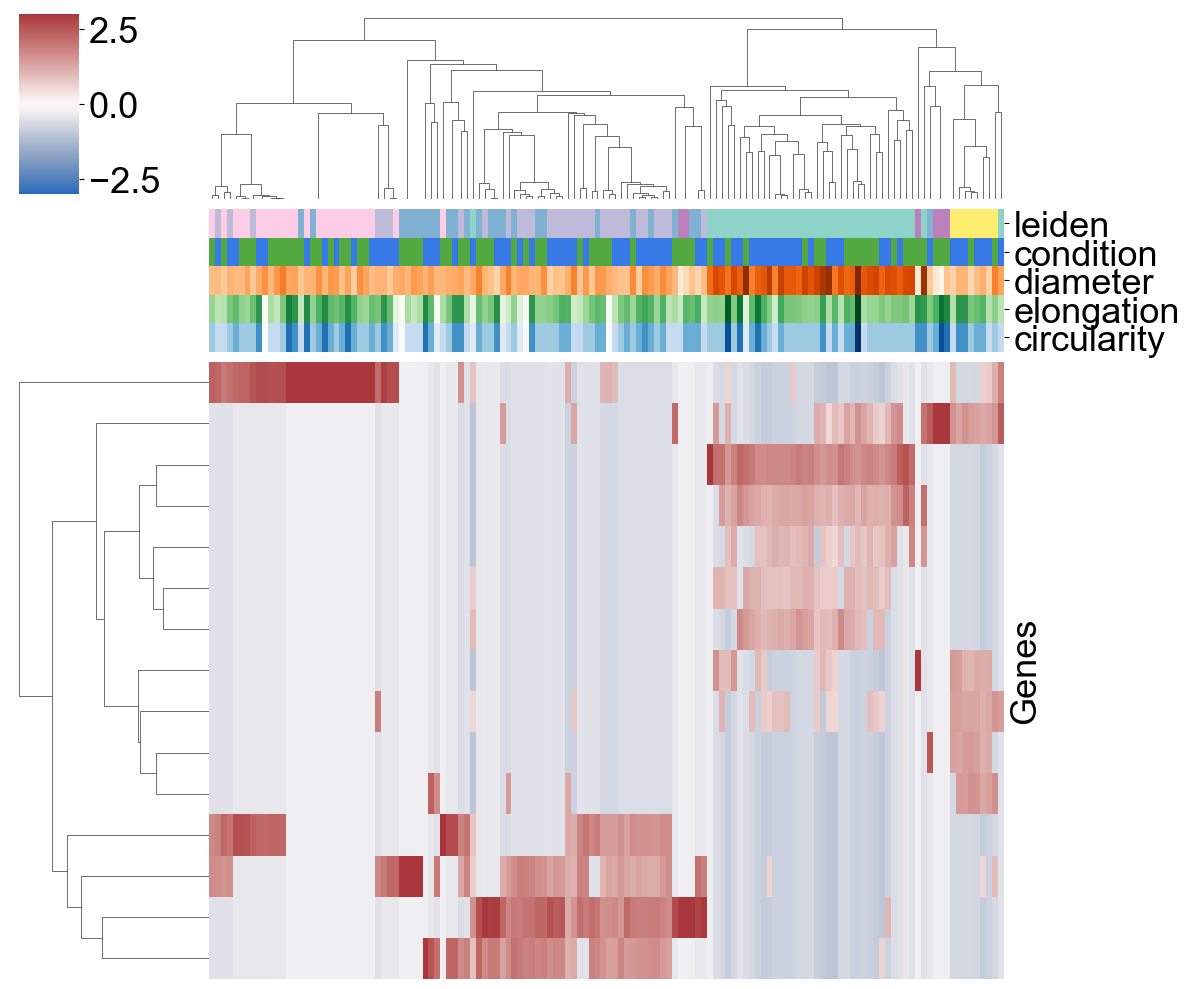

In [ ]:
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)

sns.clustermap(
    expr_matrix,
    cmap="vlag",
    norm=norm,
    figsize=(12, 10),
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=False,
    metric="euclidean",
    method="average",
    dendrogram_ratio=0.2
)

plt.savefig("figures/PBMC_benchmarking/Heatmap_PBMC_benchmarking_topmarkers.svg", dpi=300)
plt.show()

/tmp/ipykernel_508/2169087357.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_508/2169087357.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fresh vs. Cryopreserved: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.122e-01 U_stat=2.664e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fresh vs. Cryopreserved: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:8.667e-01 U_stat=2.842e+03


/tmp/ipykernel_508/2169087357.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fresh vs. Cryopreserved: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:8.751e-01 U_stat=2.930e+03


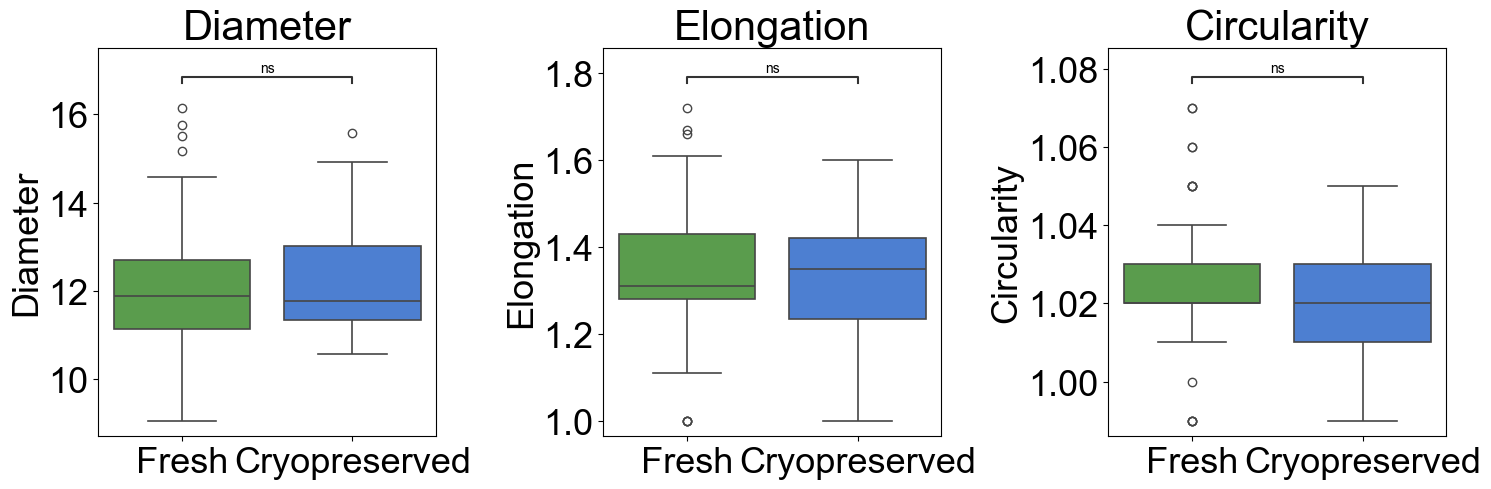

In [ ]:
from statannotations.Annotator import Annotator
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ["Diameter", "Elongation", "Circularity"]
pairs = [("Fresh", "Cryopreserved")]
order = ["Fresh", "Cryopreserved"]

palette = {
    "Fresh": "#51A940",
    "Cryopreserved": "#3779E7"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    sns.boxplot(
        x="condition",
        y=metric,
        data=adata.obs,
        order=order,
        palette=palette,
        linewidth=1.2,
        ax=ax
    )

    annotator = Annotator(
        ax,
        pairs,
        data=adata.obs,
        x="condition",
        y=metric,
        order=order
    )
    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="inside",
        comparisons_correction="fdr_bh"
    )
    annotator.apply_and_annotate()

    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.savefig(
    "figures/PBMC_benchmarking/Boxplots_morphometrics_conditions_stats.svg",
    dpi=300
)
plt.show()

In [ ]:
file_path = "pbmc_benchmarking_report_pg_matrix_DIA-NN2p3.tsv"

In [ ]:
df = pd.read_csv(file_path, sep="\t", index_col=0, encoding='latin-1')
df = df.fillna(0)

original_col_count = df.shape[1]

df = df.loc[:, (df != 0).sum() >= 0]

filtered_col_count = df.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} coluns were removed.")

0 coluns were removed.


/tmp/ipykernel_508/948627500.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_508/948627500.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


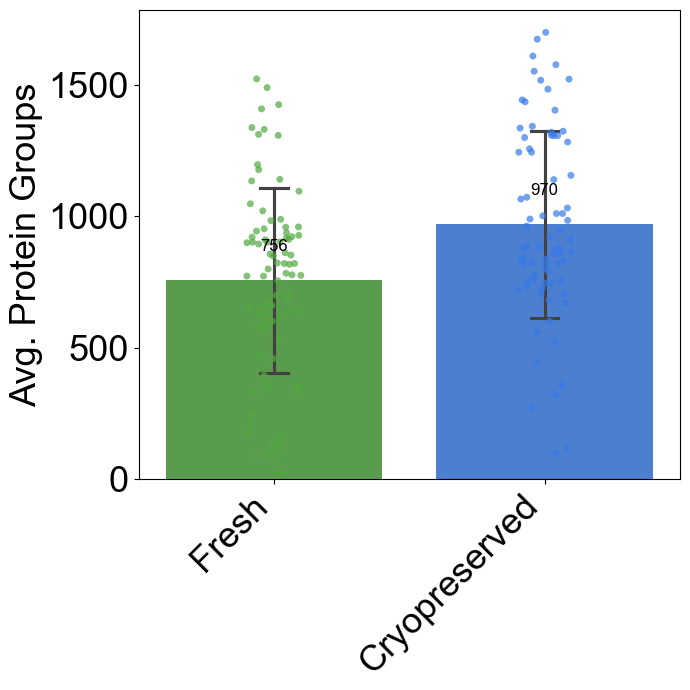

In [ ]:
protein_counts = (df > 0).sum(axis=0)

df_counts = pd.DataFrame({
    "Sample": protein_counts.index,
    "ProteinCount": protein_counts.values,
    "Condition": [extract_condition(s) for s in protein_counts.index]
})

plt.figure(figsize=(7,7))

sns.barplot(
    data=df_counts,
    x="Condition", y="ProteinCount",
    order=condition_colors.keys(),  # garante ordem fixa
    palette=condition_colors,
    errorbar="sd",
    capsize=0.1
)

sns.stripplot(
    data=df_counts,
    x="Condition", y="ProteinCount",
    order=condition_colors.keys(),
    palette=condition_colors,
    color="gray", size=5, alpha=0.7,
    jitter=True
)

group_means = df_counts.groupby("Condition")["ProteinCount"].mean()
for i, cond in enumerate(condition_colors.keys()):
    mean_val = group_means[cond]
    plt.text(
        i, mean_val + 100, f"{int(mean_val)}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

plt.ylabel("Avg. Protein Groups")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

ax = plt.gca()
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

plt.savefig("figures/PBMC_benchmarking/PBMC_benchmarking_barplot_protein_groups.svg")
plt.show()


In [ ]:
file_path = "pbmc_benchmarking_report_pg_matrix_DIA-NN2p3.tsv"
df = pd.read_csv(file_path, sep='\t')
#df = df.fillna(0)

condition_colors = {
    "Fresh": "#51A940",
    "Cryopreserved": "#3779E7"
}

condition_keywords = list(condition_colors.keys())

condition_keywords = ["Fresh", "Cryopreserved"]

condition_columns = {cond: [col for col in df.columns if cond in col] for cond in condition_keywords}

summary_data = {}
for cond, cols in condition_columns.items():
    mean_values = df[cols].mean(axis=1, skipna=True)
    std_values = df[cols].std(axis=1, skipna=True)
    cv_values = (std_values / mean_values) * 100
    cv_values.replace([np.inf, -np.inf], np.nan, inplace=True)

    summary_data[f"{cond}_mean"] = mean_values
    summary_data[f"{cond}_std"] = std_values
    summary_data[f"{cond}_cv"] = cv_values

summary_df = pd.DataFrame(summary_data)
summary_df.insert(0, "Genes", df["Genes"])

summary_df.to_csv("Final_Mean_Std_CV_Table.csv", sep='\t', index=False)

summary_df

,Genes,Fresh_mean,Fresh_std,Fresh_cv,Cryopreserved_mean,Cryopreserved_std,Cryopreserved_cv
0,ago/01,1367.334200,1290.927329,94.411983,664.104667,324.552819,48.870733
1,A2M,3639.620800,3178.743756,87.337224,1185.904750,1355.833593,114.329047
2,A2ML1,5844.078600,5950.763061,101.825514,5556.618053,10099.024978,181.747690
3,AADAC,573.860500,59.980333,10.452075,1546.301750,1641.194256,106.136739
4,AAK1,325.180857,143.005420,43.977195,434.329600,299.131719,68.872054
...,...,...,...,...,...,...,...
3088,ZNF263,1169.914500,870.110575,74.373860,1064.145200,450.159665,42.302466
3089,ZNF324,4906.163684,2060.317666,41.994475,4604.716905,1921.906646,41.737781
3090,ZRANB2,391.739000,321.537010,82.079397,301.052250,131.351575,43.630823
3091,ZYX,4353.683429,4627.816763,106.296584,2706.370436,1368.755865,50.575333


/tmp/ipykernel_508/49504987.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="CV (%)", data=cv_data, palette=[condition_colors[cond.replace("_cv", "")] for cond in cv_columns])


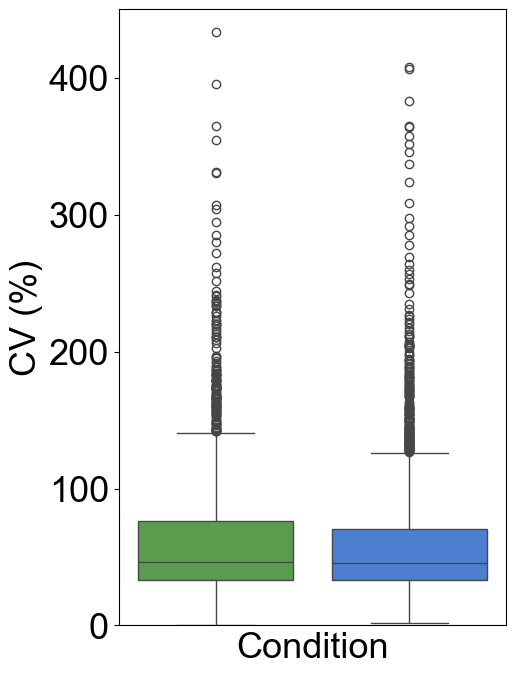

,Genes,Fresh_mean,Fresh_std,Fresh_cv,Cryopreserved_mean,Cryopreserved_std,Cryopreserved_cv
0,ago/01,1367.334200,1290.927329,94.411983,664.104667,324.552819,48.870733
1,A2M,3639.620800,3178.743756,87.337224,1185.904750,1355.833593,114.329047
2,A2ML1,5844.078600,5950.763061,101.825514,5556.618053,10099.024978,181.747690
3,AADAC,573.860500,59.980333,10.452075,1546.301750,1641.194256,106.136739
4,AAK1,325.180857,143.005420,43.977195,434.329600,299.131719,68.872054
...,...,...,...,...,...,...,...
3088,ZNF263,1169.914500,870.110575,74.373860,1064.145200,450.159665,42.302466
3089,ZNF324,4906.163684,2060.317666,41.994475,4604.716905,1921.906646,41.737781
3090,ZRANB2,391.739000,321.537010,82.079397,301.052250,131.351575,43.630823
3091,ZYX,4353.683429,4627.816763,106.296584,2706.370436,1368.755865,50.575333


In [ ]:
cv_columns = [f"{cond}_cv" for cond in condition_keywords]
cv_data = summary_df[cv_columns].melt(var_name="Condition", value_name="CV (%)")

plt.figure(figsize=(5, 8))
sns.boxplot(x="Condition", y="CV (%)", data=cv_data, palette=[condition_colors[cond.replace("_cv", "")] for cond in cv_columns])
plt.xticks(rotation=45, ha='right')
plt.xticks([])
plt.ylabel("CV (%)")
plt.title("")
plt.ylim(0, 450)

plt.savefig("figures/PBMC_benchmarking/CV_Distribution.svg")
plt.show()

summary_df

In [ ]:
!zip -r figures_PBMC_benchmarking.zip figures/PBMC_benchmarking/

  adding: figures/PBMC_benchmarking/ (stored 0%)
  adding: figures/PBMC_benchmarking/UMAP_PBMC_benchmarking.svg (deflated 74%)
  adding: figures/PBMC_benchmarking/dotplot_PBMC_benchmarking_dotplot.svg (deflated 80%)
  adding: figures/PBMC_benchmarking/UMAP_PBMC_benchmarking_Protein_Count.svg (deflated 72%)
  adding: figures/PBMC_benchmarking/umap_PG_UMAP_highlight_leiden_selected_genes.svg (deflated 88%)
  adding: figures/PBMC_benchmarking/UMAP_PBMC_benchmarking_Leiden_r1.svg (deflated 75%)
  adding: figures/PBMC_benchmarking/CV_Distribution.svg (deflated 87%)
  adding: figures/PBMC_benchmarking/PCA_PBMC_benchmarking.svg (deflated 84%)
  adding: figures/PBMC_benchmarking/Boxplot_PBMC_benchmarking.svg (deflated 77%)
  adding: figures/PBMC_benchmarking/Correlation_Diameter_PG_PBMC_benchmarking.svg (deflated 77%)
  adding: figures/PBMC_benchmarking/PBMC_benchmarking_barplot_protein_groups.svg (deflated 82%)
  adding: figures/PBMC_benchmarking/Boxplots_morphometrics_conditions_stats.svg (d